# D2C Customer Churn Intelligence
## Objective
The objective of this analysis is to understand behavior, identity data quality issues, explore churn-related patterns, and generate business hypotheses before building predictive models.
Snapshot Date: 2025-09-30
Target: Predict whether customer will churn within the next 60 days.

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

CHART_DIR = Path("../outputs/charts")
TABLE_DIR = Path("../outputs/tables")

CHART_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


# Load Datasets

In [5]:

customers = pd.read_csv("../data/customers.csv")
orders = pd.read_csv("../data/orders.csv")
tickets = pd.read_csv("../data/support_tickets.csv")
web = pd.read_csv("../data/web_events_snapshot.csv")
campaigns = pd.read_csv("../data/intervention_history.csv")
churn = pd.read_csv("../data/churn_labels.csv")


# Dataset Overview

In [6]:
# Dataset Overview

datasets = {
    "customers": customers,
    "orders": orders,
    "tickets": tickets,
    "web": web,
    "campaigns": campaigns,
    "churn": churn
}

overview = pd.DataFrame(
    [
        [name, df.shape[0], df.shape[1]]
        for name, df in datasets.items()
    ],
    columns=["Dataset", "Rows", "Columns"]
)

# Display nicely in notebook
display(overview)

# Save CSV
overview.to_csv(
    TABLE_DIR / "dataset_overview.csv",
    index=False
)

# Save Markdown table
with open(
    TABLE_DIR / "dataset_overview.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(overview.to_markdown(index=False))

# Save table as image
fig, ax = plt.subplots(figsize=(8, 3))

ax.axis("off")

table = ax.table(
    cellText=overview.values,
    colLabels=overview.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title(
    "Dataset Overview",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.savefig(
    CHART_DIR / "dataset_overview_table.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

print("✓ Dataset overview saved successfully")

,Dataset,Rows,Columns
0,customers,2400,9
1,orders,10009,10
2,tickets,1921,8
3,web,2400,10
4,campaigns,2400,5
5,churn,2400,4


✓ Dataset overview saved successfully


## Dataset Overview - Key Observations

- The analysis uses six datasets covering customer profiles, transactions, support interactions, web activity, campaign history, and churn labels.
- The customer dataset acts as the master table containing 2,400 unique customers.
- The orders dataset is the largest source with 10,009 transaction records.
- Support ticket data contains 1,921 records, indicating that not every customer interacts with customer support.
- Web activity, campaign history, and churn labels contain one record per customer and can be joined directly using `customer_id`.
- All datasets share a common key (`customer_id`), enabling customer-level analysis across multiple behavioral dimensions.

# Schema Inspection

The purpose of this section is to understand the structure, data types, cardinality, and completeness of each dataset before performing data-quality checks and exploratory analysis.

Key objectives:

- Verify column data types
- Identify potential primary keys
- Identify nullable columns
- Understand dataset granularity (customer-level vs transaction-level)
- Detect potential issues that may affect joins or downstream analysis

In [7]:
schema_summary = []

for dataset_name, df in datasets.items():

    for column in df.columns:

        schema_summary.append([
            dataset_name,
            column,
            str(df[column].dtype),
            df[column].isnull().sum(),
            df[column].nunique()
        ])

schema_df = pd.DataFrame(
    schema_summary,
    columns=[
        "Dataset",
        "Column",
        "Data Type",
        "Missing Values",
        "Unique Values"
    ]
)

display(schema_df.head(20))

schema_df.to_csv(
    TABLE_DIR / "schema_summary.csv",
    index=False
)

print("✓ Schema summary saved successfully")

,Dataset,Column,Data Type,Missing Values,Unique Values
0,customers,customer_id,str,0,2400
1,customers,signup_date,str,0,609
2,customers,city_tier,str,0,3
3,customers,age_group,str,0,4
4,customers,acquisition_channel,str,0,6
5,customers,loyalty_tier,str,1386,3
6,customers,preferred_category,str,0,6
7,customers,skin_type,str,401,5
8,customers,marketing_consent,str,0,2
9,orders,order_id,str,0,10009


✓ Schema summary saved successfully


In [8]:
schema_preview = schema_df.head(15)

fig, ax = plt.subplots(figsize=(12, 5))

ax.axis("off")

table = ax.table(
    cellText=schema_preview.values,
    colLabels=schema_preview.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.4)

plt.title(
    "Schema Summary Preview",
    fontsize=14,
    fontweight="bold"
)

plt.savefig(
    CHART_DIR / "schema_summary_preview.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# Data Quality Audit

Before performing exploratory analysis, it is important to assess the quality of the datasets.

This section focuses on:

- Missing values
- Duplicate-like records
- Invalid values
- Outliers
- Join consistency
- Leakage risks

Poor data quality can lead to misleading business conclusions and unreliable predictive models.

In [9]:
# Missing Values Analysis

missing_summary = []

for dataset_name, df in datasets.items():

    total_rows = len(df)

    for column in df.columns:

        missing_count = df[column].isnull().sum()

        missing_percentage = round(
            (missing_count / total_rows) * 100,
            2
        )

        missing_summary.append([
            dataset_name,
            column,
            missing_count,
            missing_percentage
        ])

# Create dataframe
missing_df = pd.DataFrame(
    missing_summary,
    columns=[
        "Dataset",
        "Column",
        "Missing Count",
        "Missing Percentage"
    ]
)

# Keep only columns that actually contain missing values
missing_only = (
    missing_df[
        missing_df["Missing Count"] > 0
    ]
    .sort_values(
        by="Missing Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

# Display in notebook
display(missing_only)

# Save CSV
missing_only.to_csv(
    TABLE_DIR / "missing_values_summary.csv",
    index=False
)

print("✓ Missing values summary saved")

,Dataset,Column,Missing Count,Missing Percentage
0,customers,loyalty_tier,1386,57.75
1,customers,skin_type,401,16.71
2,orders,rating,80,0.80


✓ Missing values summary saved


## Missing Values Analysis

Missing values may represent either:

1. Data collection issues
2. Legitimate business states

Understanding the reason for missingness is important before deciding whether to remove, impute, or retain records.

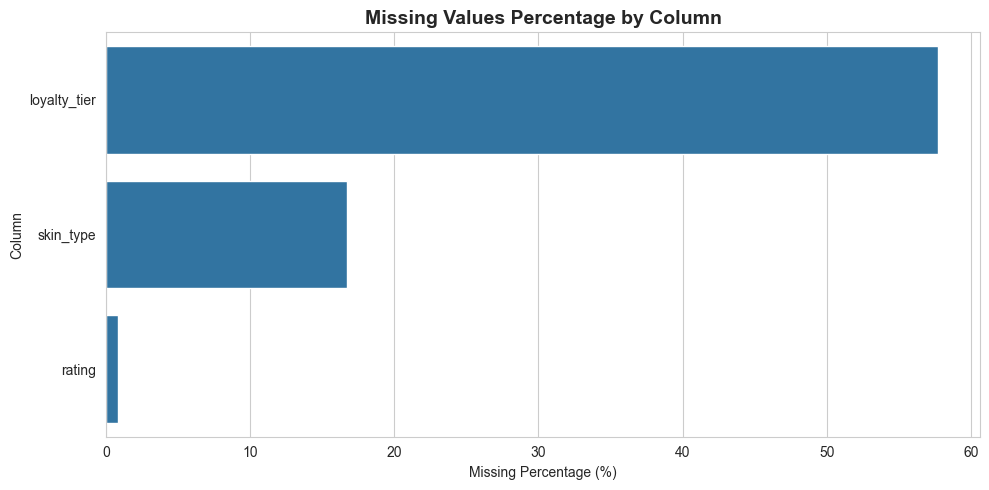

In [10]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=missing_only,
    x="Missing Percentage",
    y="Column"
)

plt.title(
    "Missing Values Percentage by Column",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Missing Percentage (%)")
plt.ylabel("Column")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "missing_values_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Missing Value Findings

The missing-value audit identified three columns containing incomplete information.

### Key Findings

1. **Loyalty Tier (57.75% Missing)**

   - This is the most significant source of missingness.
   - Based on the data dictionary, null values indicate customers who are not enrolled in the loyalty program rather than a system error.
   - Missingness itself may therefore carry business meaning and should be retained as a separate category during future modeling.

2. **Skin Type (16.71% Missing)**

   - Missing values likely represent customers who chose not to provide this information during registration.
   - Since skin type is a self-reported profile attribute, missing values do not necessarily indicate poor data quality.

3. **Order Rating (0.80% Missing)**

   - A small number of customers did not leave ratings after purchases.
   - The impact on analysis is minimal, but missing ratings should be handled before calculating average satisfaction metrics.

### Recommendation

- Do not drop records because of missing values.
- Treat missing loyalty-tier values as "Not Enrolled".
- Treat missing skin-type values as "Unknown".
- Handle missing ratings separately when computing customer satisfaction features.

## Duplicate-Like Record Analysis

Duplicate records are a common data quality issue in transactional systems and can lead to inflated revenue, order counts, and customer activity metrics.

The data dictionary explicitly mentions the existence of duplicate-like order identifiers ending with the suffix `_DUP`.

The objective of this analysis is to:

- Identify duplicate-like transactions.
- Assess their frequency.
- Determine whether they should be removed before downstream analysis.
- Evaluate their potential impact on customer-level metrics.

In [11]:
# Duplicate-like Orders Audit

duplicate_like_orders = orders[
    orders["order_id"].str.contains(
        "_DUP",
        na=False
    )
].copy()

duplicate_summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Duplicate-like Orders",
        "Duplicate-like Percentage"
    ],
    "Value": [
        len(orders),
        len(duplicate_like_orders),
        round(
            (len(duplicate_like_orders) / len(orders)) * 100,
            2
        )
    ]
})

display(duplicate_summary)

duplicate_summary.to_csv(
    TABLE_DIR /
    "duplicate_summary.csv",
    index=False
)

duplicate_like_orders.to_csv(
    TABLE_DIR /
    "duplicate_like_orders.csv",
    index=False
)

print("✓ Duplicate analysis saved")

,Metric,Value
0,Total Orders,10009.00
1,Duplicate-like Orders,12.00
2,Duplicate-like Percentage,0.12


✓ Duplicate analysis saved


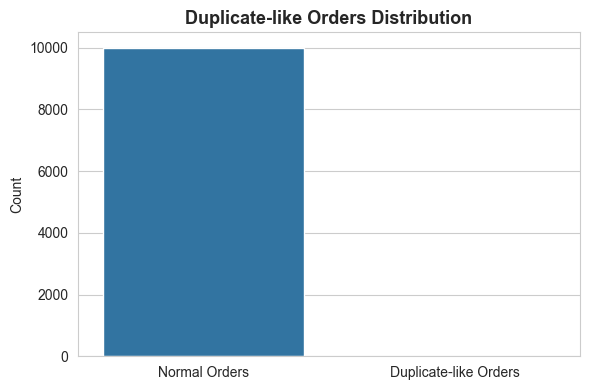

In [12]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=["Normal Orders", "Duplicate-like Orders"],
    y=[
        len(orders) - len(duplicate_like_orders),
        len(duplicate_like_orders)
    ]
)

plt.title(
    "Duplicate-like Orders Distribution",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "duplicate_like_orders_distribution.png",
    dpi=300
)

plt.show()

### Duplicate-Like Record Findings

A total of 12 duplicate-like order records were identified out of 10,009 transactions, representing approximately 0.12% of all orders.

Key observations:

- The number of duplicate-like records is very small relative to the overall dataset size.
- Duplicate-like records are distributed across multiple customers and categories.
- Some duplicate-like orders occur before the snapshot date, while others occur after the snapshot date.
- These records appear to be intentionally included as part of the data-quality exercise.

Recommendation:

- Flag duplicate-like records during feature engineering.
- Investigate whether they represent true duplicate transactions or replicated entries before removing them.
- For Part 1, retain the records and document their existence.

## Invalid Values & Data Consistency Checks

In addition to missing values and duplicate-like records, datasets may contain values that violate expected business rules.

Examples include:

- Negative quantities
- Discounts greater than 100%
- Invalid ratings
- Negative delivery times
- Invalid sentiment scores

These checks help ensure that downstream analysis is based on realistic and trustworthy data.

In [13]:
invalid_summary = []

# Quantity Check
invalid_summary.append([
    "Quantity < 1",
    (orders["quantity"] < 1).sum()
])

# Discount Check
invalid_summary.append([
    "Discount > 100%",
    (orders["discount_pct"] > 1).sum()
])

invalid_summary.append([
    "Discount < 0%",
    (orders["discount_pct"] < 0).sum()
])

# Delivery Days
invalid_summary.append([
    "Negative Delivery Days",
    (orders["delivery_days"] < 0).sum()
])

# Rating Check
invalid_summary.append([
    "Rating Outside 1-5",
    (
        (orders["rating"] < 1) |
        (orders["rating"] > 5)
    ).sum()
])

# Sentiment Check
invalid_summary.append([
    "Sentiment < -1",
    (tickets["sentiment_score"] < -1).sum()
])

invalid_summary.append([
    "Sentiment > 1",
    (tickets["sentiment_score"] > 1).sum()
])

invalid_df = pd.DataFrame(
    invalid_summary,
    columns=[
        "Validation Rule",
        "Invalid Records"
    ]
)

display(invalid_df)

invalid_df.to_csv(
    TABLE_DIR /
    "invalid_values_summary.csv",
    index=False
)

print("✓ Invalid values audit saved")

,Validation Rule,Invalid Records
0,Quantity < 1,0
1,Discount > 100%,0
2,Discount < 0%,0
3,Negative Delivery Days,0
4,Rating Outside 1-5,0
5,Sentiment < -1,0
6,Sentiment > 1,0


✓ Invalid values audit saved


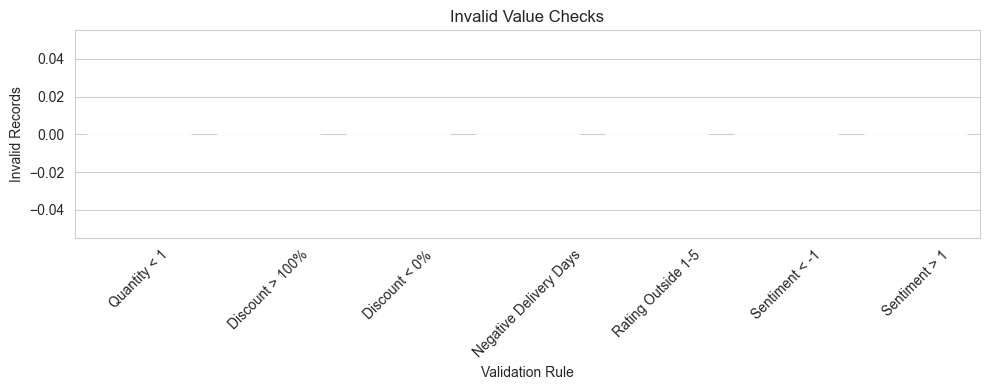

In [14]:
plt.figure(figsize=(10,4))

sns.barplot(
    data=invalid_df,
    x="Validation Rule",
    y="Invalid Records"
)

plt.xticks(rotation=45)

plt.title(
    "Invalid Value Checks"
)

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "invalid_values_audit.png",
    dpi=300
)

plt.show()

### Invalid Values Audit Findings

A series of business-rule validation checks were performed across the transaction and support datasets.

The audit evaluated:

- Order quantity
- Discount percentages
- Delivery duration
- Customer ratings
- Ticket sentiment scores

#### Results

No invalid records were detected.

Key findings:

- All order quantities were greater than or equal to one.
- No discounts exceeded 100% or fell below 0%.
- No negative delivery durations were identified.
- All customer ratings were within the expected range of 1 to 5.
- All sentiment scores fell within the valid interval of -1 to +1.

#### Business Impact

The absence of invalid values suggests that core transactional and support-system validation controls are functioning correctly.

This increases confidence in the reliability of downstream customer behavior analysis and future predictive modeling activities.

## Outlier Analysis

Outliers can significantly influence customer-level metrics such as average order value, total spend, and customer lifetime value.

The objective of this analysis is to identify unusually large transactions and assess their potential impact on future analysis and modeling activities.

The `gross_amount` field is of particular interest because the data dictionary indicates the presence of intentionally injected high-value transactions.

In [16]:
orders["gross_amount"].describe()

count    10009.000000
mean       743.898504
std        600.564068
min        149.000000
25%        432.850000
50%        597.060000
75%        907.430000
max      24789.380000
Name: gross_amount, dtype: float64

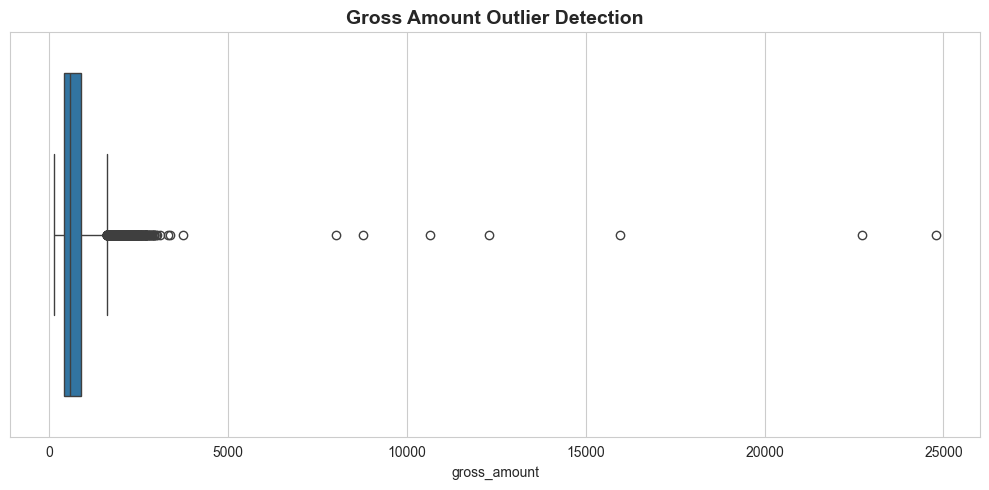

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=orders["gross_amount"]
)

plt.title(
    "Gross Amount Outlier Detection",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "gross_amount_boxplot.png",
    dpi=300
)

plt.show()

In [18]:
Q1 = orders["gross_amount"].quantile(0.25)
Q3 = orders["gross_amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = orders[
    (orders["gross_amount"] < lower_bound) |
    (orders["gross_amount"] > upper_bound)
]

print(f"Outlier Orders: {len(outliers)}")

outliers[
    [
        "order_id",
        "customer_id",
        "gross_amount"
    ]
].head()

Outlier Orders: 536


,order_id,customer_id,gross_amount
45,ORD000034,CUST00014,1781.74
73,ORD000055,CUST00020,2710.51
84,ORD000067,CUST00025,1987.35
93,ORD000073,CUST00027,2128.34
159,ORD000130,CUST00042,1908.63


### Outlier Analysis Findings

The gross transaction amount (`gross_amount`) was analyzed using the Interquartile Range (IQR) method.

#### Key Statistics

| Metric | Value |
|----------|----------:|
| Mean Order Value | ₹743.90 |
| Median Order Value | ₹597.06 |
| Maximum Order Value | ₹24,789.38 |
| Outlier Orders | 536 |
| Total Orders | 10,009 |
| Outlier Percentage | 5.36% |

#### Observations

- The maximum order value is substantially larger than the median transaction value.
- The distribution is positively skewed, indicating the presence of a small number of unusually large purchases.
- Approximately 5.36% of orders were flagged as outliers using the IQR method.
- These transactions may represent bulk purchases, premium product bundles, or exceptional customer spending behavior.

#### Recommendation

- Outliers should not be automatically removed because they may represent genuine high-value customers.
- For future modeling, robust scaling or winsorization may be considered if extreme values significantly influence model performance.
- Customer-level spending metrics should be reviewed carefully to ensure that a small number of extreme transactions do not dominate overall trends.

In [19]:
outlier_summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Outlier Orders",
        "Outlier Percentage",
        "Mean Gross Amount",
        "Median Gross Amount",
        "Maximum Gross Amount"
    ],
    "Value": [
        len(orders),
        len(outliers),
        round(
            len(outliers)/len(orders)*100,
            2
        ),
        round(
            orders["gross_amount"].mean(),
            2
        ),
        round(
            orders["gross_amount"].median(),
            2
        ),
        round(
            orders["gross_amount"].max(),
            2
        )
    ]
})

display(outlier_summary)

outlier_summary.to_csv(
    TABLE_DIR /
    "outlier_summary.csv",
    index=False
)

print("✓ Outlier summary saved")

,Metric,Value
0,Total Orders,10009.00
1,Outlier Orders,536.00
2,Outlier Percentage,5.36
3,Mean Gross Amount,743.90
4,Median Gross Amount,597.06
5,Maximum Gross Amount,24789.38


✓ Outlier summary saved


In [20]:
fig, ax = plt.subplots(figsize=(8,3))

ax.axis("off")

table = ax.table(
    cellText=outlier_summary.values,
    colLabels=outlier_summary.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2,1.5)

plt.title(
    "Outlier Summary",
    fontsize=14,
    fontweight="bold"
)

plt.savefig(
    CHART_DIR /
    "outlier_summary_table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# Data Consistency & Leakage Analysis

In [21]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

snapshot_date = pd.Timestamp(
    "2025-09-30"
)

post_snapshot_orders = orders[
    orders["order_date"] >
    snapshot_date
]

print(
    f"Post-Snapshot Orders: {len(post_snapshot_orders)}"
)

post_snapshot_orders.head()

Post-Snapshot Orders: 1872


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
7,ORD008129,CUST00002,2025-10-24,Skin Care,1,562.21,0.16,1,0,5.0
8,ORD008130,CUST00002,2025-10-26,Skin Care,1,569.89,0.18,4,0,4.0
15,ORD008132,CUST00005,2025-10-29,Hair Care,1,379.14,0.34,4,0,2.0
16,ORD008131,CUST00005,2025-11-19,Baby Care,3,980.38,0.22,4,0,4.0
22,ORD008133,CUST00006,2025-10-06,Baby Care,1,217.30,0.38,4,0,4.0


## Date Consistency & Leakage Analysis

The project documentation defines **2025-09-30** as the customer snapshot date.

Any transaction occurring after this date would not have been known at prediction time and therefore must not be used when building churn prediction features.

Using future transactions would introduce **data leakage**, causing models to learn information that would not be available in a real-world deployment scenario.

This section evaluates the presence and magnitude of post-snapshot transactions.

# Leakage Summary Table

In [22]:
leakage_summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Post-Snapshot Orders",
        "Post-Snapshot Percentage"
    ],
    "Value": [
        len(orders),
        len(post_snapshot_orders),
        round(
            len(post_snapshot_orders) /
            len(orders) * 100,
            2
        )
    ]
})

display(leakage_summary)

leakage_summary.to_csv(
    TABLE_DIR /
    "leakage_summary.csv",
    index=False
)

print("✓ Leakage summary saved")

,Metric,Value
0,Total Orders,10009.0
1,Post-Snapshot Orders,1872.0
2,Post-Snapshot Percentage,18.7


✓ Leakage summary saved


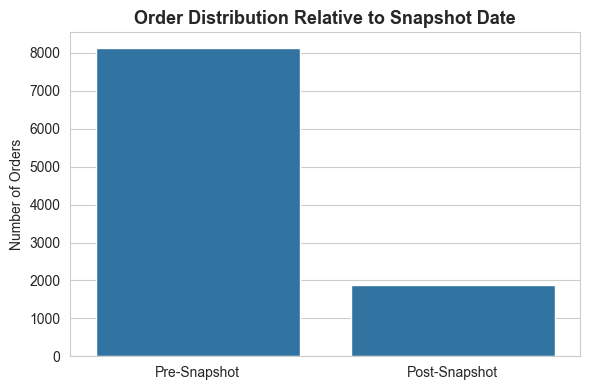

In [23]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=[
        "Pre-Snapshot",
        "Post-Snapshot"
    ],
    y=[
        len(orders) -
        len(post_snapshot_orders),

        len(post_snapshot_orders)
    ]
)

plt.title(
    "Order Distribution Relative to Snapshot Date",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "post_snapshot_orders.png",
    dpi=300
)

plt.show()

# Join Validation

In [24]:
customer_ids = set(customers["customer_id"])

join_validation = pd.DataFrame({
    "Dataset": [
        "orders",
        "tickets",
        "web",
        "campaigns",
        "churn"
    ],
    "Records": [
        len(orders),
        len(tickets),
        len(web),
        len(campaigns),
        len(churn)
    ],
    "Orphan Records": [
        (~orders["customer_id"].isin(customer_ids)).sum(),
        (~tickets["customer_id"].isin(customer_ids)).sum(),
        (~web["customer_id"].isin(customer_ids)).sum(),
        (~campaigns["customer_id"].isin(customer_ids)).sum(),
        (~churn["customer_id"].isin(customer_ids)).sum()
    ]
})

display(join_validation)

,Dataset,Records,Orphan Records
0,orders,10009,0
1,tickets,1921,0
2,web,2400,0
3,campaigns,2400,0
4,churn,2400,0


# Join Validation

Customer-level analytics require reliable joins across all datasets.

To validate data integrity, each dataset was checked for customer identifiers that do not exist in the master customer table.

Such records are commonly referred to as orphan records and can lead to missing features, inaccurate aggregations, and incorrect customer profiles.

In [25]:
join_validation.to_csv(
    TABLE_DIR /
    "join_validation_summary.csv",
    index=False
)

print("✓ Join validation summary saved")

✓ Join validation summary saved


In [26]:
fig, ax = plt.subplots(figsize=(8,3))

ax.axis("off")

table = ax.table(
    cellText=join_validation.values,
    colLabels=join_validation.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2,1.5)

plt.title(
    "Join Validation Summary",
    fontsize=14,
    fontweight="bold"
)

plt.savefig(
    CHART_DIR /
    "join_validation_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

### Join Validation Findings

All datasets were successfully validated against the master customer table.

#### Results

| Dataset | Orphan Records |
|----------|----------:|
| Orders | 0 |
| Support Tickets | 0 |
| Web Activity | 0 |
| Campaign History | 0 |
| Churn Labels | 0 |

#### Key Observations

- No orphan customer identifiers were detected.
- Every transaction, support interaction, campaign record, web activity record, and churn label can be linked to a valid customer profile.
- This indicates strong referential integrity across the entire data ecosystem.

#### Business Impact

Reliable joins are critical for customer-level analytics and churn modeling.

The absence of orphan records ensures that customer features can be constructed consistently across all available data sources.

# Exploratory Data Analysis (EDA)

## Customer Demographics & Profile Analysis

This section explores the composition of the customer base and identifies demographic patterns that may influence customer behavior and churn.

In [27]:
customers["age_group"].value_counts()

age_group
25-34    1045
18-24     560
35-44     534
45+       261
Name: count, dtype: int64

## Age Group Distribution

Understanding the age composition of the customer base helps identify the dominant customer segments and provides context for future churn analysis.

Age groups may exhibit different purchasing patterns, engagement behaviors, and retention characteristics.

In [28]:
age_distribution = (
    customers["age_group"]
    .value_counts()
    .reset_index()
)

age_distribution.columns = [
    "Age Group",
    "Customer Count"
]

display(age_distribution)

age_distribution.to_csv(
    TABLE_DIR /
    "age_group_distribution.csv",
    index=False
)

print("✓ Age group table saved")

,Age Group,Customer Count
0,25-34,1045
1,18-24,560
2,35-44,534
3,45+,261


✓ Age group table saved


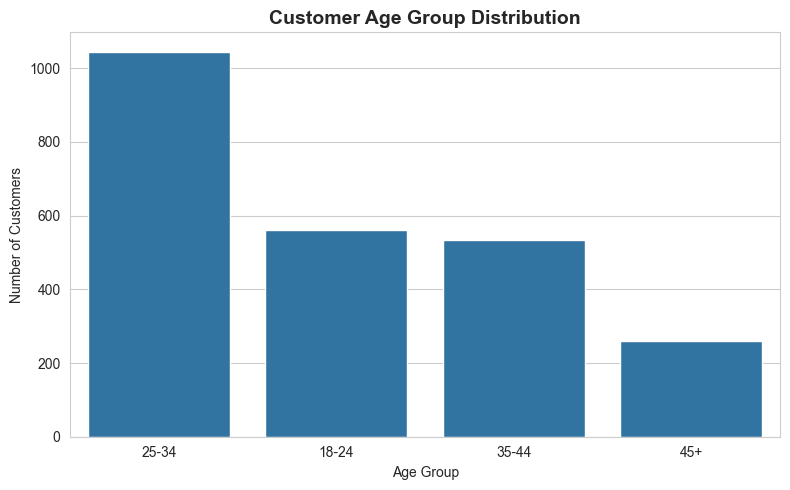

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customers,
    x="age_group",
    order=customers["age_group"]
        .value_counts()
        .index
)

plt.title(
    "Customer Age Group Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "customer_age_group_distribution.png",
    dpi=300
)

plt.show()

### Age Group Findings

The customer base is concentrated in younger and middle-aged segments.

#### Key Statistics

| Age Group | Customers |
|-----------|-----------:|
| 25–34 | 1,045 |
| 18–24 | 560 |
| 35–44 | 534 |
| 45+ | 261 |

#### Observations

- Customers aged **25–34** represent the largest segment, accounting for approximately 43.5% of the customer base.
- The **18–24** and **35–44** groups contribute similar volumes of customers.
- Customers aged **45+** represent the smallest segment.

#### Business Interpretation

The customer base is heavily concentrated among younger consumers, suggesting that marketing, product positioning, and customer engagement strategies are primarily attracting early-career and mid-career demographics.

Future churn analysis should investigate whether retention behavior differs across age groups.

In [30]:
customers["city_tier"].value_counts()

city_tier
Tier 1    1005
Tier 2     870
Tier 3     525
Name: count, dtype: int64

In [31]:
customers["acquisition_channel"].value_counts()

acquisition_channel
Instagram        517
Google Search    466
Marketplace      456
Referral         396
Organic          334
Influencer       231
Name: count, dtype: int64

## Customer Acquisition Channel Distribution

Acquisition channels represent the first touchpoint between customers and the brand.

Understanding customer acquisition sources helps evaluate marketing effectiveness and identify channels that contribute the largest share of customers.

Differences in customer quality across channels may later influence churn behavior.

In [32]:
acquisition_distribution = (
    customers["acquisition_channel"]
    .value_counts()
    .reset_index()
)

acquisition_distribution.columns = [
    "Acquisition Channel",
    "Customer Count"
]

display(acquisition_distribution)

acquisition_distribution.to_csv(
    TABLE_DIR /
    "acquisition_channel_distribution.csv",
    index=False
)

print("✓ Acquisition channel table saved")

,Acquisition Channel,Customer Count
0,Instagram,517
1,Google Search,466
2,Marketplace,456
3,Referral,396
4,Organic,334
5,Influencer,231


✓ Acquisition channel table saved


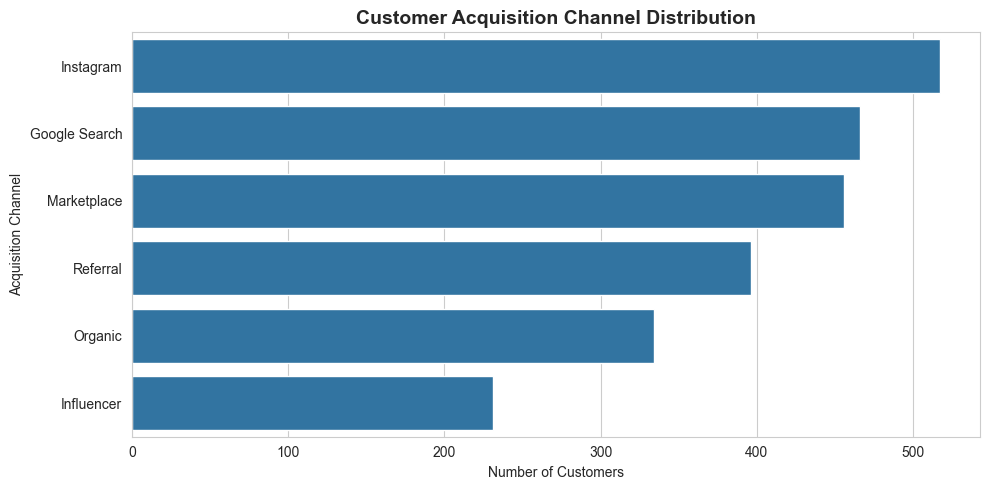

In [33]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=customers,
    y="acquisition_channel",
    order=customers["acquisition_channel"]
        .value_counts()
        .index
)

plt.title(
    "Customer Acquisition Channel Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Customers")
plt.ylabel("Acquisition Channel")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "customer_acquisition_channel_distribution.png",
    dpi=300
)

plt.show()

### Acquisition Channel Findings

Customer acquisition is distributed across multiple marketing channels, reducing dependence on a single source.

#### Key Statistics

| Channel | Customers |
|----------|----------:|
| Instagram | 517 |
| Google Search | 466 |
| Marketplace | 456 |
| Referral | 396 |
| Organic | 334 |
| Influencer | 231 |

#### Observations

- Instagram is the largest acquisition channel, contributing 517 customers.
- Google Search and Marketplace channels also contribute substantial customer volumes.
- Referral-based acquisition accounts for a meaningful share of the customer base.
- Influencer campaigns contribute the smallest customer segment.

#### Business Interpretation

The company appears to have a diversified acquisition strategy.

However, acquisition volume alone does not indicate customer quality.

Future churn analysis should evaluate whether customers acquired through different channels exhibit different retention and engagement patterns.

In [34]:
customers["loyalty_tier"].value_counts(dropna=False)

loyalty_tier
NaN         1386
Silver       590
Gold         319
Platinum     105
Name: count, dtype: int64

## Loyalty Tier Distribution

The loyalty program is designed to improve customer retention and encourage repeat purchases.

Understanding membership distribution provides insight into customer engagement and potential retention opportunities.

Customers without a loyalty tier are treated separately because missing values likely indicate non-enrollment rather than a data-quality issue.

In [35]:
loyalty_distribution = (
    customers["loyalty_tier"]
    .fillna("Not Enrolled")
    .value_counts()
    .reset_index()
)

loyalty_distribution.columns = [
    "Loyalty Tier",
    "Customer Count"
]

display(loyalty_distribution)

loyalty_distribution.to_csv(
    TABLE_DIR /
    "loyalty_tier_distribution.csv",
    index=False
)

print("✓ Loyalty tier table saved")

,Loyalty Tier,Customer Count
0,Not Enrolled,1386
1,Silver,590
2,Gold,319
3,Platinum,105


✓ Loyalty tier table saved


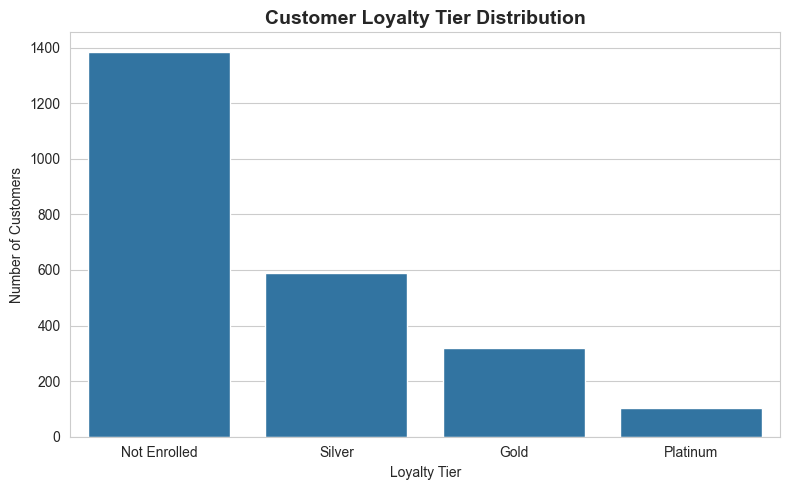

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=customers["loyalty_tier"]
        .fillna("Not Enrolled"),
    order=customers["loyalty_tier"]
        .fillna("Not Enrolled")
        .value_counts()
        .index
)

plt.title(
    "Customer Loyalty Tier Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Loyalty Tier")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "customer_loyalty_tier_distribution.png",
    dpi=300
)

plt.show()

### Key Findings

- 57.75% of customers are not enrolled in the loyalty program.
- Silver is the largest active loyalty tier with 590 customers.
- Gold and Platinum memberships represent a relatively small portion of the customer base.
- The large non-enrolled segment presents a potential retention opportunity.

### Business Insight

Loyalty program participation may influence customer retention and should be investigated further during churn analysis.

## Preferred Product Category

Understanding category preferences helps identify which product segments attract the largest customer base.

In [37]:
preferred_category = (
    customers["preferred_category"]
    .value_counts()
    .reset_index()
)

preferred_category.columns = [
    "Preferred Category",
    "Customer Count"
]

display(preferred_category)

preferred_category.to_csv(
    TABLE_DIR /
    "preferred_category_distribution.csv",
    index=False
)

print("✓ Preferred category table saved")

,Preferred Category,Customer Count
0,Skin Care,731
1,Hair Care,507
2,Baby Care,347
3,Makeup,326
4,Wellness,251
5,Fragrance,238


✓ Preferred category table saved


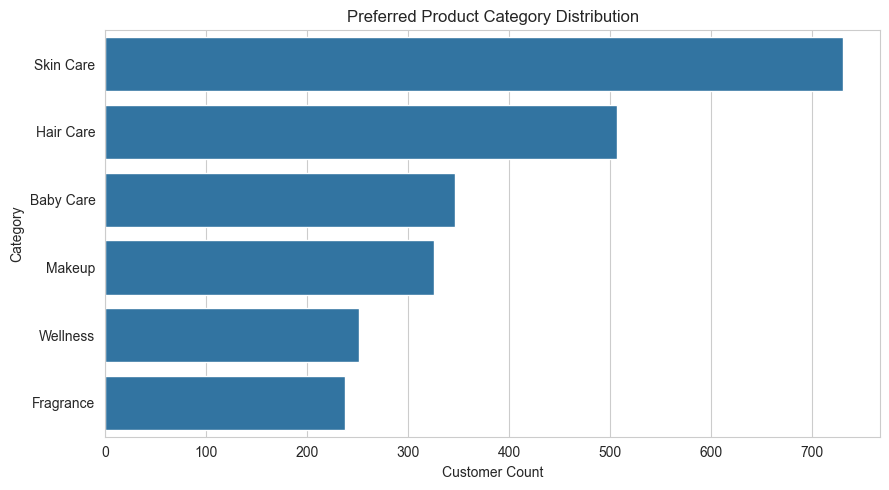

In [38]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=customers,
    y="preferred_category",
    order=customers["preferred_category"]
        .value_counts()
        .index
)

plt.title(
    "Preferred Product Category Distribution"
)

plt.xlabel("Customer Count")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "preferred_category_distribution.png",
    dpi=300
)

plt.show()

### Key Findings

- Skin Care is the most preferred category with 731 customers.
- Hair Care is the second-largest category with 507 customers.
- Fragrance and Wellness have the smallest customer segments.
- Customer preferences are distributed across multiple product categories.

### Business Insight

Category preference may influence purchase frequency, engagement, and churn behavior. Future analysis should evaluate whether certain product categories have higher churn rates.

## Marketing Consent Distribution

Marketing consent determines whether customers can be contacted through promotional campaigns and retention initiatives.

In [39]:
marketing_consent = (
    customers["marketing_consent"]
    .value_counts()
    .reset_index()
)

marketing_consent.columns = [
    "Marketing Consent",
    "Customer Count"
]

display(marketing_consent)

marketing_consent.to_csv(
    TABLE_DIR /
    "marketing_consent_distribution.csv",
    index=False
)

print("✓ Marketing consent table saved")

,Marketing Consent,Customer Count
0,Yes,1760
1,No,640


✓ Marketing consent table saved


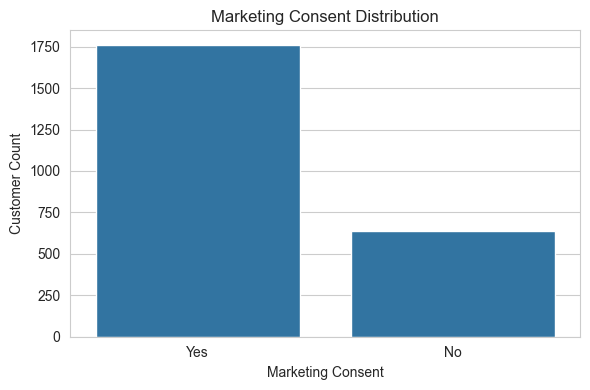

In [40]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=customers,
    x="marketing_consent",
    order=customers["marketing_consent"]
        .value_counts()
        .index
)

plt.title(
    "Marketing Consent Distribution"
)

plt.xlabel("Marketing Consent")
plt.ylabel("Customer Count")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "marketing_consent_distribution.png",
    dpi=300
)

plt.show()

### Key Findings

- 1,760 customers (73.3%) have opted into marketing communications.
- 640 customers (26.7%) have not provided marketing consent.
- The majority of customers are reachable through promotional and retention campaigns.

### Business Insight

The high marketing-consent rate provides a strong opportunity for personalized retention campaigns. Future churn analysis should evaluate whether customers who engage with marketing communications are less likely to churn.

# Order Behavior Analysis

Order history provides insight into customer purchasing patterns, spending behavior, satisfaction levels, and return activity.

This section explores transaction-level characteristics that may later be associated with churn risk.

## Orders Per Customer

Purchase frequency is a strong indicator of customer engagement and loyalty.

Customers with very few purchases are often more likely to churn than customers who purchase repeatedly.

In [41]:
orders_per_customer = (
    orders.groupby("customer_id")
    .size()
    .reset_index(name="order_count")
)

display(
    orders_per_customer.describe()
)

orders_per_customer.to_csv(
    TABLE_DIR /
    "orders_per_customer_summary.csv",
    index=False
)

print("✓ Orders per customer summary saved")

,order_count
count,2400.000000
mean,4.170417
std,2.626960
min,1.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,17.000000


✓ Orders per customer summary saved


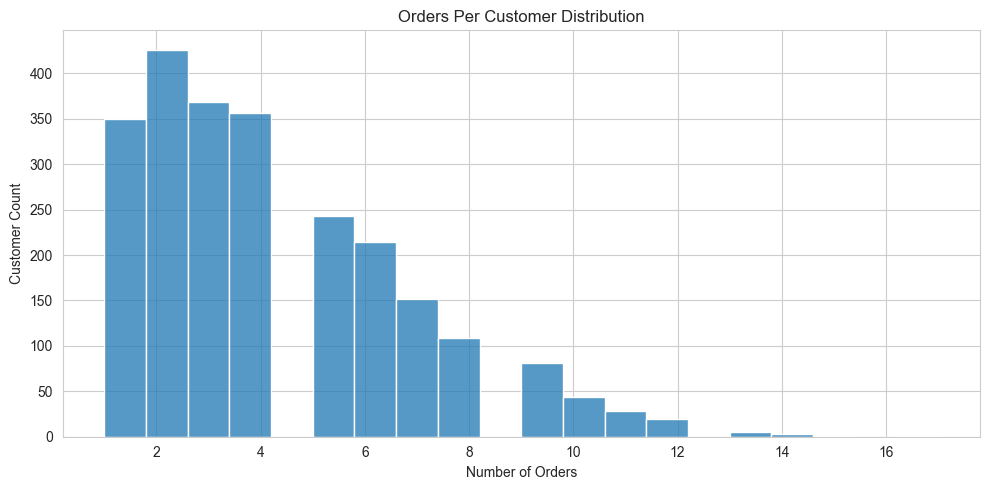

In [42]:
plt.figure(figsize=(10,5))

sns.histplot(
    orders_per_customer["order_count"],
    bins=20
)

plt.title(
    "Orders Per Customer Distribution"
)

plt.xlabel("Number of Orders")
plt.ylabel("Customer Count")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "orders_per_customer_distribution.png",
    dpi=300
)

plt.show()

### Key Findings

- Customers place an average of 4.17 orders.
- Half of all customers have placed 4 or fewer orders.
- 25% of customers have placed only 1–2 orders.
- The most active customers have placed up to 17 orders.

### Business Insight

Purchase frequency varies significantly across the customer base. Customers with fewer orders may represent lower engagement segments and should be examined further during churn analysis.

## Order Value Distribution

Order value is a key indicator of customer spending behavior.

Analyzing transaction amounts helps identify spending patterns, high-value purchases, and revenue concentration across the customer base.

In [43]:
gross_amount_summary = pd.DataFrame({
    "Metric": [
        "Mean Order Value",
        "Median Order Value",
        "Minimum Order Value",
        "Maximum Order Value"
    ],
    "Value": [
        round(orders["gross_amount"].mean(), 2),
        round(orders["gross_amount"].median(), 2),
        round(orders["gross_amount"].min(), 2),
        round(orders["gross_amount"].max(), 2)
    ]
})

display(gross_amount_summary)

gross_amount_summary.to_csv(
    TABLE_DIR /
    "gross_amount_summary.csv",
    index=False
)

print("✓ Gross amount summary saved")

,Metric,Value
0,Mean Order Value,743.90
1,Median Order Value,597.06
2,Minimum Order Value,149.00
3,Maximum Order Value,24789.38


✓ Gross amount summary saved


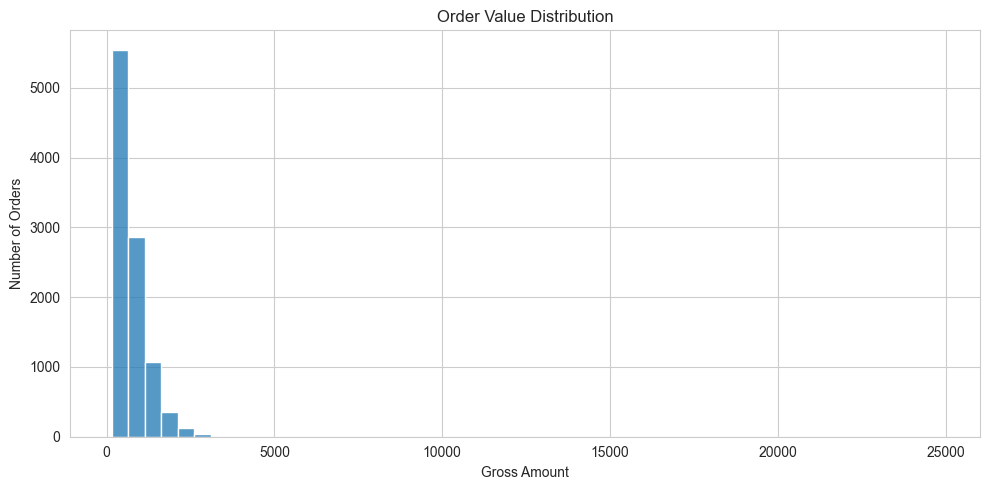

In [44]:
plt.figure(figsize=(10,5))

sns.histplot(
    orders["gross_amount"],
    bins=50
)

plt.title(
    "Order Value Distribution"
)

plt.xlabel("Gross Amount")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "gross_amount_distribution.png",
    dpi=300
)

plt.show()

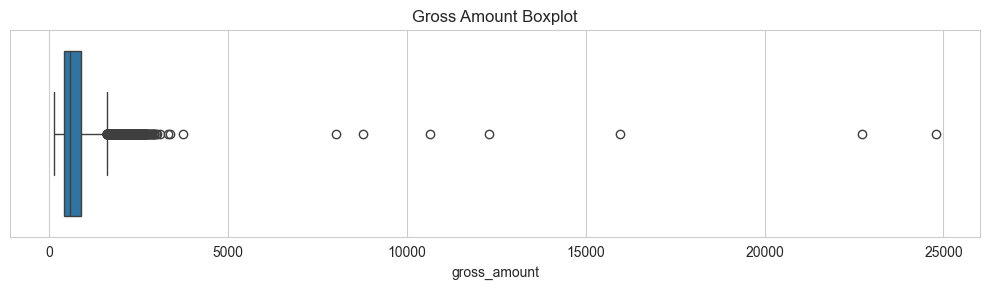

In [45]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=orders["gross_amount"]
)

plt.title(
    "Gross Amount Boxplot"
)

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "gross_amount_boxplot.png",
    dpi=300
)

plt.show()

### Key Findings

- The average order value is ₹743.90.
- The median order value is ₹597.06.
- Order values range from ₹149.00 to ₹24,789.38.
- The large gap between the mean and maximum value indicates the presence of high-value transactions.

### Business Insight

Customer spending is positively skewed, with a small number of very large purchases contributing disproportionately to revenue. High-value customers should be identified and analyzed separately during retention planning.

## Return Behavior Analysis

Product returns can be an indicator of customer dissatisfaction and may influence future purchasing behavior.

This section evaluates the prevalence of returned orders within the customer base.

In [46]:
return_summary = (
    orders["returned"]
    .value_counts()
    .reset_index()
)

return_summary.columns = [
    "Returned",
    "Order Count"
]

return_summary["Returned"] = (
    return_summary["Returned"]
    .map({
        0: "Not Returned",
        1: "Returned"
    })
)

display(return_summary)

return_summary.to_csv(
    TABLE_DIR /
    "return_behavior_summary.csv",
    index=False
)

print("✓ Return behavior summary saved")

,Returned,Order Count
0,Not Returned,9334
1,Returned,675


✓ Return behavior summary saved


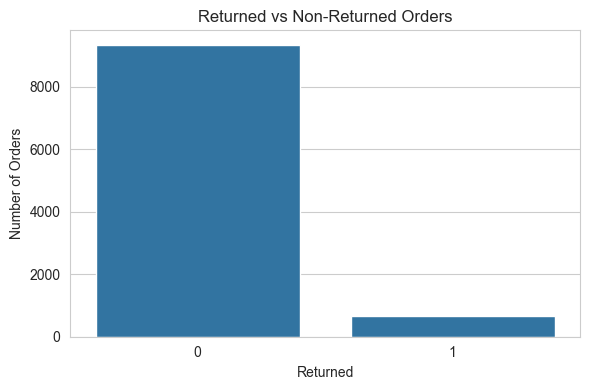

In [47]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=orders["returned"]
)

plt.title(
    "Returned vs Non-Returned Orders"
)

plt.xlabel("Returned")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "return_behavior_distribution.png",
    dpi=300
)

plt.show()

In [48]:
return_rate = round(
    orders["returned"].mean() * 100,
    2
)

print(
    f"Return Rate: {return_rate}%"
)

Return Rate: 6.74%


### Key Findings

- Out of 10,009 orders, 675 were returned.
- The overall return rate is 6.74%.
- The majority of orders (93.26%) were successfully retained without returns.

### Business Insight

Although the return rate is relatively low, returned orders may indicate dissatisfaction, product mismatch, or fulfillment issues. Customers with repeated returns should be examined further during churn analysis.

## Customer Rating Analysis

Customer ratings provide direct feedback regarding product and purchase experience.

Lower ratings may indicate dissatisfaction and could be associated with increased churn risk.

In [49]:
rating_summary = (
    orders["rating"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)

rating_summary.columns = [
    "Rating",
    "Count"
]

display(rating_summary)

rating_summary.to_csv(
    TABLE_DIR /
    "rating_distribution.csv",
    index=False
)

print("✓ Rating distribution saved")

,Rating,Count
0,1.0,539
1,2.0,803
2,3.0,1664
3,4.0,3173
4,5.0,3750
5,NaN,80


✓ Rating distribution saved


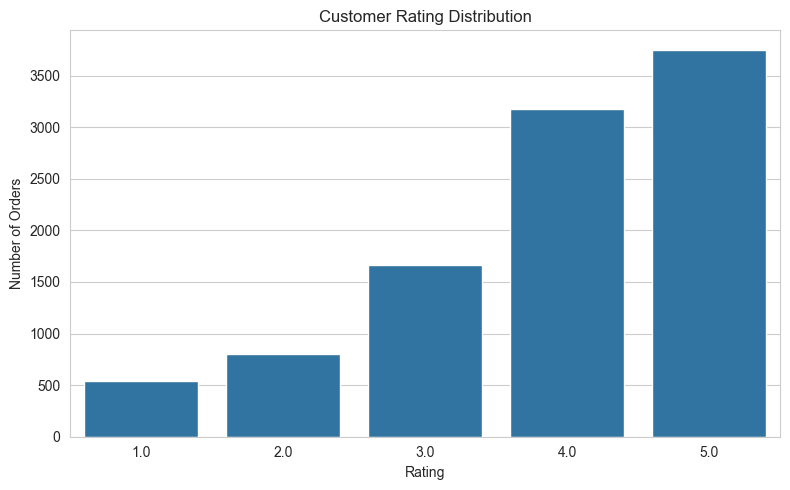

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=orders,
    x="rating",
    order=sorted(
        orders["rating"]
        .dropna()
        .unique()
    )
)

plt.title(
    "Customer Rating Distribution"
)

plt.xlabel("Rating")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "customer_rating_distribution.png",
    dpi=300
)

plt.show()

In [51]:
rating_stats = pd.DataFrame({
    "Metric": [
        "Average Rating",
        "Median Rating",
        "Missing Ratings"
    ],
    "Value": [
        round(
            orders["rating"].mean(),
            2
        ),
        round(
            orders["rating"].median(),
            2
        ),
        int(
            orders["rating"]
            .isnull()
            .sum()
        )
    ]
})

display(rating_stats)

rating_stats.to_csv(
    TABLE_DIR /
    "rating_summary.csv",
    index=False
)

,Metric,Value
0,Average Rating,3.89
1,Median Rating,4.00
2,Missing Ratings,80.00


### Key Findings

- The average customer rating is 3.89 out of 5.
- The median rating is 4.0, indicating generally positive customer feedback.
- Ratings of 4 and 5 account for the majority of reviews.
- Only 80 orders (0.8%) have missing ratings.

### Business Insight

Overall customer satisfaction appears healthy. However, customers providing ratings of 1 or 2 may represent at-risk segments and should be investigated further during churn analysis.

## Delivery Performance Analysis

Delivery speed plays an important role in customer satisfaction and repeat purchasing behavior.

This section evaluates delivery duration across all orders.

In [52]:
delivery_summary = pd.DataFrame({
    "Metric": [
        "Average Delivery Days",
        "Median Delivery Days",
        "Minimum Delivery Days",
        "Maximum Delivery Days"
    ],
    "Value": [
        round(orders["delivery_days"].mean(), 2),
        round(orders["delivery_days"].median(), 2),
        orders["delivery_days"].min(),
        orders["delivery_days"].max()
    ]
})

display(delivery_summary)

delivery_summary.to_csv(
    TABLE_DIR /
    "delivery_summary.csv",
    index=False
)

print("✓ Delivery summary saved")

,Metric,Value
0,Average Delivery Days,4.45
1,Median Delivery Days,4.00
2,Minimum Delivery Days,1.00
3,Maximum Delivery Days,11.00


✓ Delivery summary saved


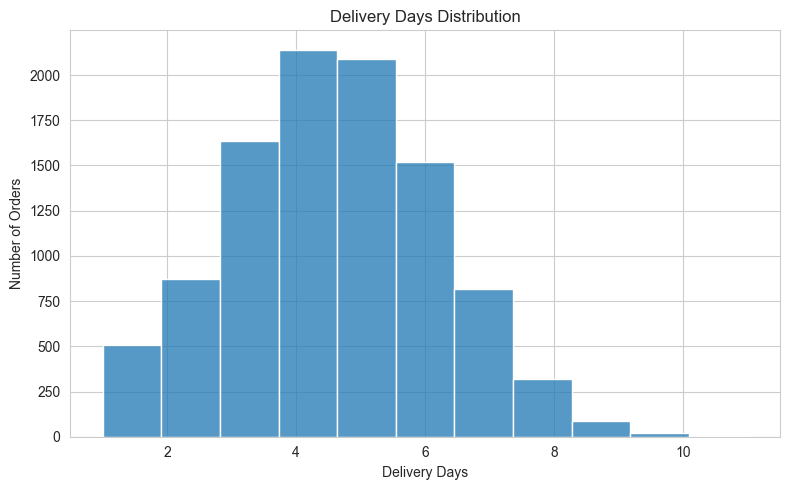

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(
    orders["delivery_days"],
    bins=11
)

plt.title(
    "Delivery Days Distribution"
)

plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "delivery_days_distribution.png",
    dpi=300
)

plt.show()

In [54]:
delivery_distribution = (
    orders["delivery_days"]
    .value_counts()
    .sort_index()
    .reset_index()
)

delivery_distribution.columns = [
    "Delivery Days",
    "Order Count"
]

display(delivery_distribution.head(15))

,Delivery Days,Order Count
0,1,507
1,2,870
2,3,1633
3,4,2140
4,5,2091
5,6,1522
6,7,816
7,8,317
8,9,88
9,10,22


### Key Findings

- The average delivery time is 4.45 days.
- The median delivery time is 4 days.
- Most orders are delivered within 3–5 days.
- Very few orders require more than 8 days for delivery.

### Business Insight

Delivery performance appears consistent across the customer base. However, customers experiencing longer delivery times may be more likely to report dissatisfaction and should be examined further during churn analysis.

# Support Ticket Analysis

Customer support interactions provide valuable insight into customer satisfaction, service quality, and potential churn drivers.

This section explores support-ticket volume, issue categories, resolution performance, and customer sentiment.

## Support Issue Categories

Understanding the most common support issues helps identify operational challenges that may affect customer experience.

In [55]:
issue_distribution = (
    tickets["issue_type"]
    .value_counts()
    .reset_index()
)

issue_distribution.columns = [
    "Issue Type",
    "Ticket Count"
]

display(issue_distribution)

issue_distribution.to_csv(
    TABLE_DIR /
    "support_issue_distribution.csv",
    index=False
)

print("✓ Support issue distribution saved")

,Issue Type,Ticket Count
0,late_delivery,377
1,refund_delay,345
2,general_query,324
3,damaged_item,277
4,wrong_item,213
5,product_reaction,194
6,payment_issue,191


✓ Support issue distribution saved


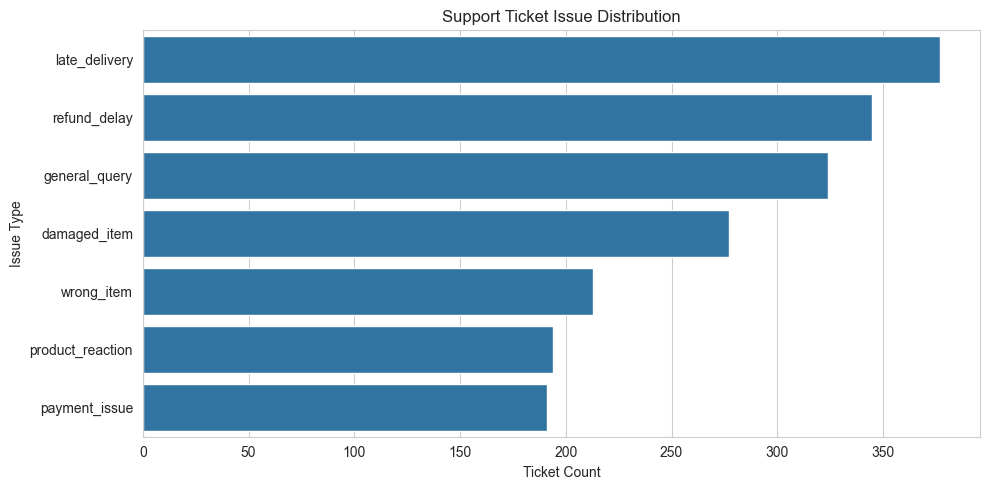

In [56]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=tickets,
    y="issue_type",
    order=tickets["issue_type"]
        .value_counts()
        .index
)

plt.title(
    "Support Ticket Issue Distribution"
)

plt.xlabel("Ticket Count")
plt.ylabel("Issue Type")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "support_issue_distribution.png",
    dpi=300
)

plt.show()

### Key Findings

- Late delivery is the most common support issue with 377 tickets.
- Refund delays account for 345 tickets and represent the second most common complaint.
- General queries contribute 324 tickets.
- Product-related issues (damaged items, wrong items, and product reactions) account for a significant portion of support volume.

### Business Insight

Delivery and refund-related issues represent the largest sources of customer dissatisfaction. These operational issues may contribute to churn and should be investigated further during retention analysis.

## Resolution Time Analysis

Resolution time measures how quickly customer issues are addressed.

Longer resolution times may negatively impact customer satisfaction and increase churn risk.

In [57]:
resolution_summary = pd.DataFrame({
    "Metric": [
        "Average Resolution Hours",
        "Median Resolution Hours",
        "Minimum Resolution Hours",
        "Maximum Resolution Hours"
    ],
    "Value": [
        round(tickets["resolution_hours"].mean(), 2),
        round(tickets["resolution_hours"].median(), 2),
        round(tickets["resolution_hours"].min(), 2),
        round(tickets["resolution_hours"].max(), 2)
    ]
})

display(resolution_summary)

resolution_summary.to_csv(
    TABLE_DIR /
    "resolution_time_summary.csv",
    index=False
)

print("✓ Resolution summary saved")

,Metric,Value
0,Average Resolution Hours,24.79
1,Median Resolution Hours,24.20
2,Minimum Resolution Hours,1.00
3,Maximum Resolution Hours,74.60


✓ Resolution summary saved


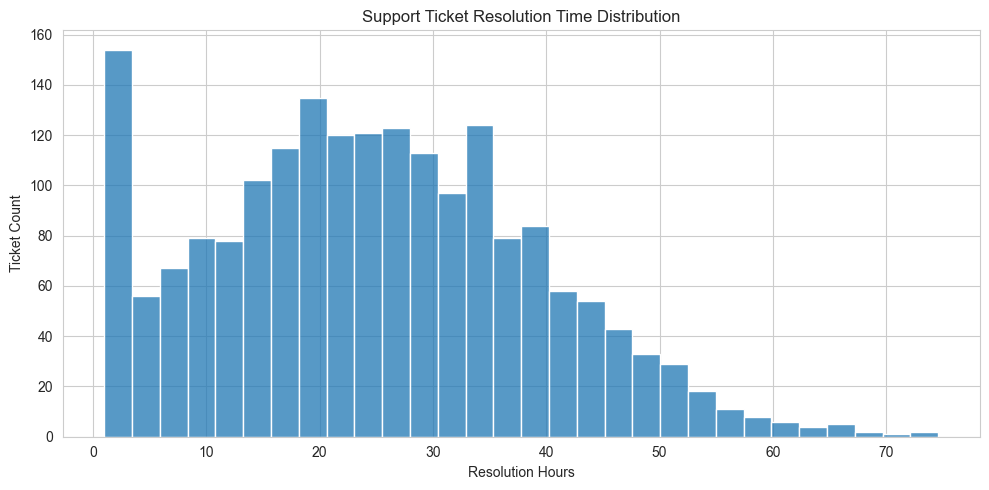

In [58]:
plt.figure(figsize=(10,5))

sns.histplot(
    tickets["resolution_hours"],
    bins=30
)

plt.title(
    "Support Ticket Resolution Time Distribution"
)

plt.xlabel("Resolution Hours")
plt.ylabel("Ticket Count")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "resolution_time_distribution.png",
    dpi=300
)

plt.show()

### Key Findings

- Average resolution time is 24.79 hours.
- Median resolution time is 24.20 hours.
- The fastest tickets are resolved within 1 hour.
- The longest resolution time observed is 74.6 hours.

### Business Insight

Most support issues are resolved within approximately one day, indicating relatively efficient customer support operations. However, customers experiencing prolonged resolution times may be more likely to become dissatisfied and disengage.

## Customer Sentiment Analysis

Sentiment scores capture the tone and satisfaction level expressed during support interactions.

Lower sentiment scores may indicate dissatisfaction and increased churn risk.

In [59]:
sentiment_summary = pd.DataFrame({
    "Metric": [
        "Average Sentiment",
        "Median Sentiment",
        "Minimum Sentiment",
        "Maximum Sentiment"
    ],
    "Value": [
        round(tickets["sentiment_score"].mean(), 2),
        round(tickets["sentiment_score"].median(), 2),
        round(tickets["sentiment_score"].min(), 2),
        round(tickets["sentiment_score"].max(), 2)
    ]
})

display(sentiment_summary)

sentiment_summary.to_csv(
    TABLE_DIR /
    "sentiment_summary.csv",
    index=False
)

print("✓ Sentiment summary saved")

,Metric,Value
0,Average Sentiment,-0.44
1,Median Sentiment,-0.49
2,Minimum Sentiment,-1.00
3,Maximum Sentiment,1.00


✓ Sentiment summary saved


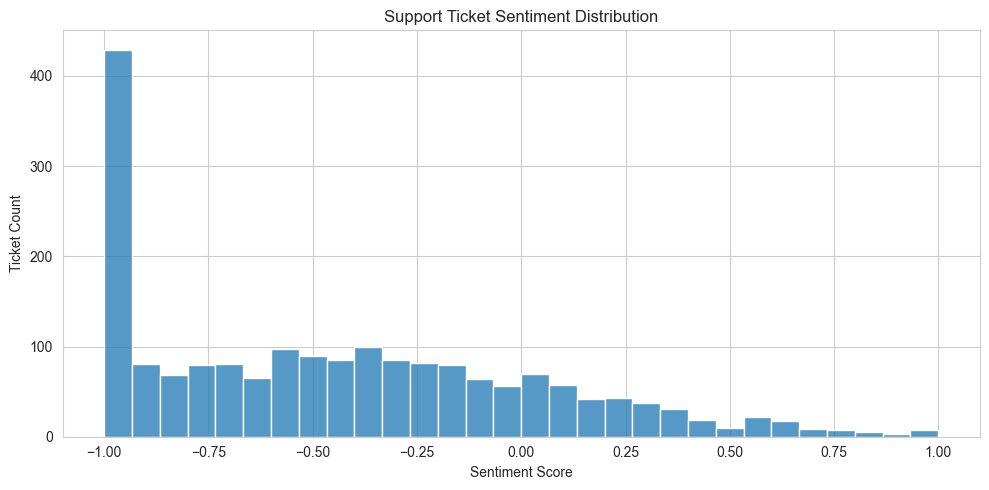

In [60]:
plt.figure(figsize=(10,5))

sns.histplot(
    tickets["sentiment_score"],
    bins=30
)

plt.title(
    "Support Ticket Sentiment Distribution"
)

plt.xlabel("Sentiment Score")
plt.ylabel("Ticket Count")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "sentiment_distribution.png",
    dpi=300
)

plt.show()

### Key Findings

- Average sentiment score is -0.44.
- Median sentiment score is -0.49.
- Sentiment scores range from -1.0 to 1.0.
- Overall customer sentiment is skewed toward the negative side.

### Business Insight

Support interactions are generally associated with negative sentiment, which is expected because customers typically contact support when facing issues. Customers with highly negative sentiment may represent an elevated churn-risk segment and should be investigated further.

## Reopened Ticket Analysis

Reopened tickets may indicate unresolved issues, poor service experience, or customer dissatisfaction.

This metric helps identify whether support cases are being effectively resolved during the first interaction.

In [61]:
reopened_summary = (
    tickets["reopened"]
    .value_counts()
    .reset_index()
)

reopened_summary.columns = [
    "Reopened",
    "Ticket Count"
]

reopened_summary["Reopened"] = (
    reopened_summary["Reopened"]
    .map({
        0: "Not Reopened",
        1: "Reopened"
    })
)

display(reopened_summary)

reopened_summary.to_csv(
    TABLE_DIR /
    "reopened_ticket_summary.csv",
    index=False
)

print("✓ Reopened ticket summary saved")

,Reopened,Ticket Count
0,Not Reopened,1581
1,Reopened,340


✓ Reopened ticket summary saved


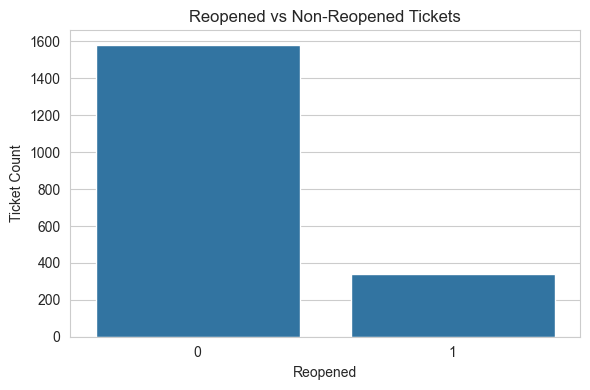

In [62]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=tickets["reopened"]
)

plt.title(
    "Reopened vs Non-Reopened Tickets"
)

plt.xlabel("Reopened")
plt.ylabel("Ticket Count")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "reopened_ticket_distribution.png",
    dpi=300
)

plt.show()

In [63]:
reopen_rate = round(
    tickets["reopened"].mean() * 100,
    2
)

print(
    f"Ticket Reopen Rate: {reopen_rate}%"
)

Ticket Reopen Rate: 17.7%


### Key Findings

- 340 tickets were reopened after initial resolution.
- The ticket reopen rate is 17.7%.
- Most tickets (82.3%) were resolved successfully without reopening.

### Business Insight

Nearly 1 in 5 support tickets required additional follow-up. Reopened tickets may indicate unresolved customer issues and could be associated with lower satisfaction and higher churn risk.

# Web Activity Analysis

Customer engagement behavior is often one of the strongest indicators of future churn.

This section evaluates browsing activity, purchase intent signals, campaign engagement, and recency metrics.

## Session Activity Analysis

Session count measures how frequently customers interact with the platform.

Lower engagement levels may indicate declining interest and increased churn risk.

In [64]:
session_summary = pd.DataFrame({
    "Metric": [
        "Average Sessions",
        "Median Sessions",
        "Minimum Sessions",
        "Maximum Sessions"
    ],
    "Value": [
        round(web["sessions_30d"].mean(), 2),
        round(web["sessions_30d"].median(), 2),
        web["sessions_30d"].min(),
        web["sessions_30d"].max()
    ]
})

display(session_summary)

session_summary.to_csv(
    TABLE_DIR /
    "session_activity_summary.csv",
    index=False
)

print("✓ Session summary saved")

,Metric,Value
0,Average Sessions,5.46
1,Median Sessions,5.00
2,Minimum Sessions,0.00
3,Maximum Sessions,25.00


✓ Session summary saved


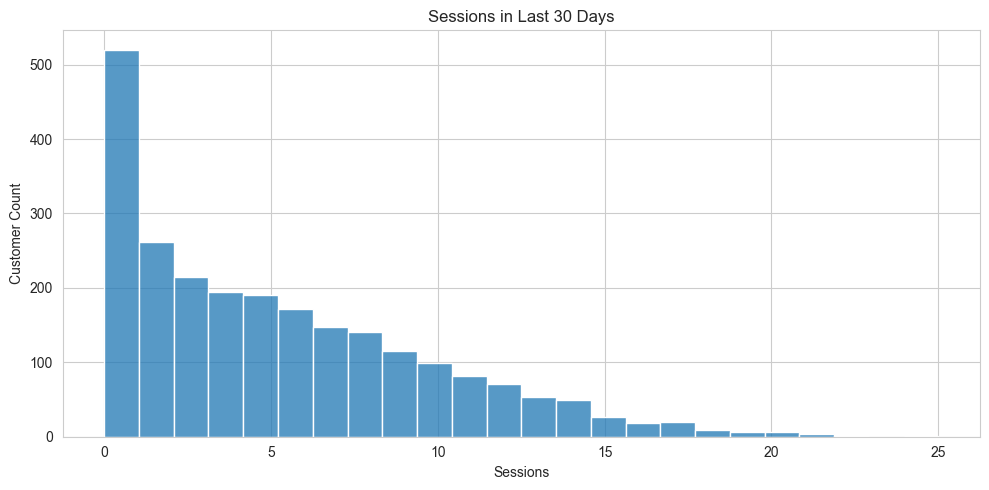

In [65]:
plt.figure(figsize=(10,5))

sns.histplot(
    web["sessions_30d"],
    bins=24
)

plt.title(
    "Sessions in Last 30 Days"
)

plt.xlabel("Sessions")
plt.ylabel("Customer Count")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "sessions_30d_distribution.png",
    dpi=300
)

plt.show()

### Key Findings

- Customers average 5.46 sessions in the last 30 days.
- The median customer completed 5 sessions.
- Some customers recorded zero sessions during the observation period.
- Highly engaged customers reached up to 25 sessions.

### Business Insight

Customer engagement varies considerably across the customer base. Customers with very low session activity may represent a high-risk churn segment and should be investigated further.

## Product View Analysis

Product views indicate customer interest in browsing and exploring products.

Higher product-view activity generally reflects stronger engagement with the platform.

In [66]:
product_view_summary = pd.DataFrame({
    "Metric": [
        "Average Product Views",
        "Median Product Views",
        "Minimum Product Views",
        "Maximum Product Views"
    ],
    "Value": [
        round(web["product_views_30d"].mean(), 2),
        round(web["product_views_30d"].median(), 2),
        web["product_views_30d"].min(),
        web["product_views_30d"].max()
    ]
})

display(product_view_summary)

product_view_summary.to_csv(
    TABLE_DIR /
    "product_view_summary.csv",
    index=False
)

print("✓ Product view summary saved")

,Metric,Value
0,Average Product Views,23.02
1,Median Product Views,18.00
2,Minimum Product Views,0.00
3,Maximum Product Views,119.00


✓ Product view summary saved


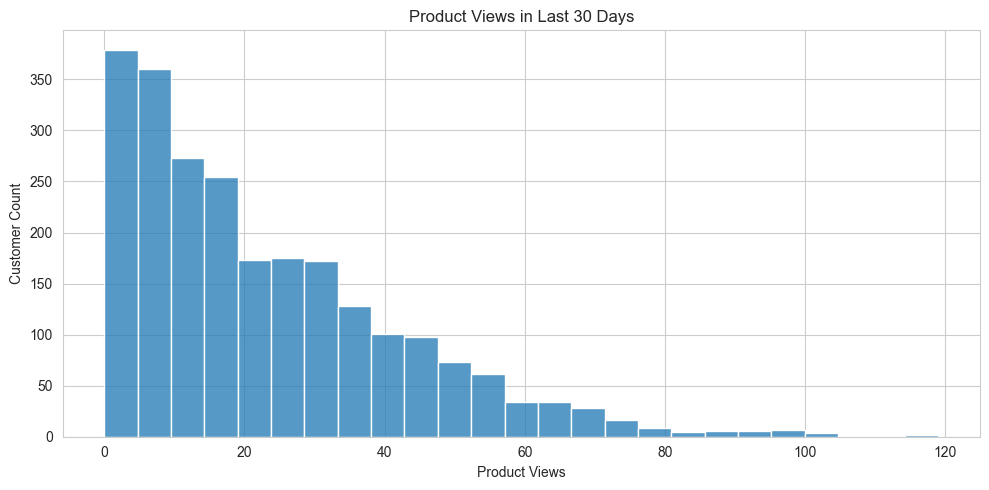

In [67]:
plt.figure(figsize=(10,5))

sns.histplot(
    web["product_views_30d"],
    bins=25
)

plt.title(
    "Product Views in Last 30 Days"
)

plt.xlabel("Product Views")
plt.ylabel("Customer Count")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "product_views_distribution.png",
    dpi=300
)

plt.show()

## Additional Engagement Metrics

Customer engagement extends beyond sessions and product views. Cart activity, campaign interactions, and recency metrics provide additional signals regarding purchase intent and platform engagement.

In [68]:
engagement_summary = pd.DataFrame({
    "Metric": [
        "Average Cart Adds",
        "Average Wishlist Adds",
        "Average Abandoned Carts",
        "Average Email Opens",
        "Average Campaign Clicks",
        "Average Days Since Last Visit"
    ],
    "Value": [
        round(web["cart_adds_30d"].mean(), 2),
        round(web["wishlist_adds_30d"].mean(), 2),
        round(web["abandoned_carts_30d"].mean(), 2),
        round(web["email_opens_30d"].mean(), 2),
        round(web["campaign_clicks_30d"].mean(), 2),
        round(web["last_visit_days_ago"].mean(), 2)
    ]
})

display(engagement_summary)

engagement_summary.to_csv(
    TABLE_DIR /
    "engagement_summary.csv",
    index=False
)

print("✓ Engagement summary saved")

,Metric,Value
0,Average Cart Adds,1.56
1,Average Wishlist Adds,0.84
2,Average Abandoned Carts,0.67
3,Average Email Opens,2.65
4,Average Campaign Clicks,0.65
5,Average Days Since Last Visit,17.65


✓ Engagement summary saved


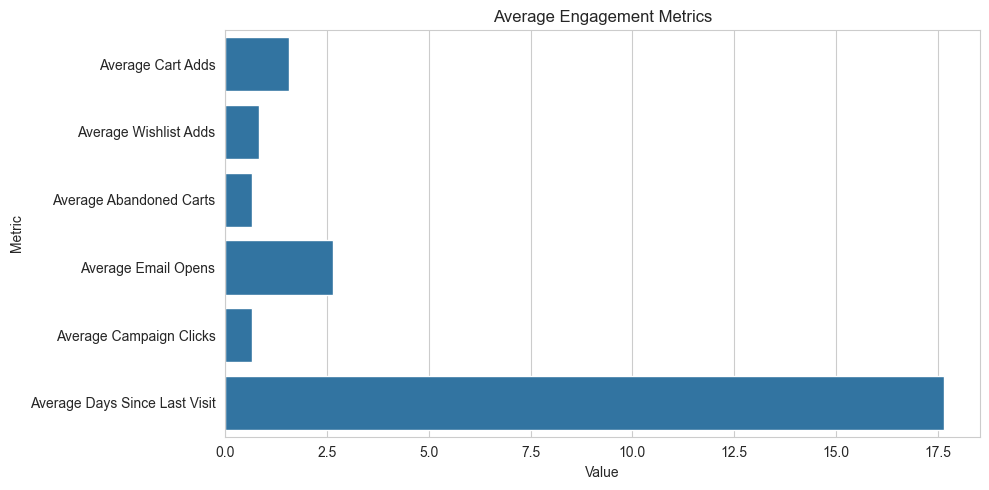

In [69]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=engagement_summary,
    x="Value",
    y="Metric"
)

plt.title(
    "Average Engagement Metrics"
)

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "engagement_metrics_summary.png",
    dpi=300
)

plt.show()

### Key Findings

- Customers add an average of 1.56 products to cart.
- Customers add less than one item to wishlists on average.
- Abandoned carts average 0.67 per customer.
- Customers open approximately 2.65 emails on average.
- Campaign click activity is relatively low at 0.65 clicks per customer.
- Customers last visited the platform approximately 17.65 days ago on average.

### Business Insight

Customer engagement decreases as actions move further down the conversion funnel. While browsing activity is healthy, campaign interaction and purchase-intent actions remain relatively limited. Recency metrics should be investigated further during churn analysis.

# Campaign Analysis

Marketing campaigns are a key retention tool. This section evaluates campaign exposure and prioritization strategies used across the customer base.

In [70]:
campaign_type_summary = (
    campaigns["last_campaign_received"]
    .value_counts()
    .reset_index()
)

campaign_type_summary.columns = [
    "Campaign Type",
    "Customer Count"
]

display(campaign_type_summary)

campaign_type_summary.to_csv(
    TABLE_DIR /
    "campaign_type_summary.csv",
    index=False
)

print("✓ Campaign summary saved")

,Campaign Type,Customer Count
0,none,507
1,new_launch,498
2,bundle_discount,473
3,free_shipping,469
4,welcome_offer,453


✓ Campaign summary saved


In [71]:
campaigns["manual_priority_bucket"].value_counts()

manual_priority_bucket
high      1163
medium     749
low        488
Name: count, dtype: int64

In [72]:
campaigns["last_campaign_received"].value_counts()

last_campaign_received
none               507
new_launch         498
bundle_discount    473
free_shipping      469
welcome_offer      453
Name: count, dtype: int64

### Key Findings

- 507 customers did not receive a recent campaign.
- New launch campaigns were the most frequently used campaign type.
- Campaign distribution is relatively balanced across all campaign categories.
- High-priority customers account for nearly half of the customer base (1,163 customers).

### Business Insight

Marketing efforts are distributed across multiple campaign types and customer segments. Campaign exposure and priority levels should be evaluated further to determine their relationship with customer retention.

# Customer-Level Master Dataset

To analyze churn effectively, customer information from multiple datasets must be consolidated into a single customer-level view.

This master table combines customer profiles, transactional behavior, support interactions, web engagement metrics, campaign information, and churn labels.

In [73]:
order_features = (
    orders.groupby("customer_id")
    .agg(
        total_orders=("order_id", "count"),
        total_spend=("gross_amount", "sum"),
        avg_order_value=("gross_amount", "mean"),
        avg_rating=("rating", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        return_rate=("returned", "mean")
    )
    .reset_index()
)

order_features.head()

,customer_id,total_orders,total_spend,avg_order_value,avg_rating,avg_delivery_days,return_rate
0,CUST00001,6,2955.57,492.595000,3.333333,3.500000,0.166667
1,CUST00002,3,1713.10,571.033333,4.333333,3.333333,0.000000
2,CUST00003,1,649.98,649.980000,2.000000,2.000000,0.000000
3,CUST00004,1,1604.04,1604.040000,2.000000,5.000000,0.000000
4,CUST00005,6,3910.43,651.738333,2.333333,5.166667,0.000000


In [74]:
ticket_features = (
    tickets.groupby("customer_id")
    .agg(
        total_tickets=("ticket_id", "count"),
        avg_resolution_hours=("resolution_hours", "mean"),
        avg_sentiment=("sentiment_score", "mean"),
        reopen_rate=("reopened", "mean")
    )
    .reset_index()
)

ticket_features.head()

,customer_id,total_tickets,avg_resolution_hours,avg_sentiment,reopen_rate
0,CUST00001,2,4.35,0.14,0.0
1,CUST00002,1,1.00,0.00,0.0
2,CUST00005,1,37.70,-1.00,0.0
3,CUST00006,2,17.60,-0.68,0.5
4,CUST00008,1,6.00,0.08,0.0


In [75]:
customer_master = (
    customers
    .merge(order_features,
           on="customer_id",
           how="left")
    .merge(ticket_features,
           on="customer_id",
           how="left")
    .merge(web,
           on="customer_id",
           how="left")
    .merge(campaigns,
           on="customer_id",
           how="left")
    .merge(churn,
           on="customer_id",
           how="left")
)

print(customer_master.shape)

customer_master.head()

(2400, 35)


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,total_orders,total_spend,avg_order_value,avg_rating,avg_delivery_days,return_rate,total_tickets,avg_resolution_hours,avg_sentiment,reopen_rate,snapshot_date_x,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,snapshot_date_y,last_campaign_received,last_campaign_cost,manual_priority_bucket,snapshot_date,churn_next_60d,split
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,6,2955.57,492.595000,3.333333,3.500000,0.166667,2.0,4.35,0.14,0.0,2025-09-30,1,4,0,0,0,2,0,20,2025-09-30,welcome_offer,25,high,2025-09-30,1,train
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,3,1713.10,571.033333,4.333333,3.333333,0.000000,1.0,1.00,0.00,0.0,2025-09-30,8,31,4,2,3,0,0,0,2025-09-30,free_shipping,12,medium,2025-09-30,0,train
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,1,649.98,649.980000,2.000000,2.000000,0.000000,NaN,NaN,NaN,NaN,2025-09-30,1,3,0,0,0,0,0,26,2025-09-30,none,18,high,2025-09-30,1,train
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,1,1604.04,1604.040000,2.000000,5.000000,0.000000,NaN,NaN,NaN,NaN,2025-09-30,1,6,0,0,0,0,0,14,2025-09-30,free_shipping,40,high,2025-09-30,1,train
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,6,3910.43,651.738333,2.333333,5.166667,0.000000,1.0,37.70,-1.00,0.0,2025-09-30,18,95,4,1,1,3,1,9,2025-09-30,welcome_offer,18,medium,2025-09-30,0,train


In [76]:
customer_master.columns.tolist()

['customer_id',
 'signup_date',
 'city_tier',
 'age_group',
 'acquisition_channel',
 'loyalty_tier',
 'preferred_category',
 'skin_type',
 'marketing_consent',
 'total_orders',
 'total_spend',
 'avg_order_value',
 'avg_rating',
 'avg_delivery_days',
 'return_rate',
 'total_tickets',
 'avg_resolution_hours',
 'avg_sentiment',
 'reopen_rate',
 'snapshot_date_x',
 'sessions_30d',
 'product_views_30d',
 'cart_adds_30d',
 'wishlist_adds_30d',
 'abandoned_carts_30d',
 'email_opens_30d',
 'campaign_clicks_30d',
 'last_visit_days_ago',
 'snapshot_date_y',
 'last_campaign_received',
 'last_campaign_cost',
 'manual_priority_bucket',
 'snapshot_date',
 'churn_next_60d',
 'split']

In [77]:
customer_master.to_csv(
    TABLE_DIR /
    "customer_master_dataset.csv",
    index=False
)

print("✓ Customer master dataset saved")

✓ Customer master dataset saved


In [78]:
print(customer_master.shape)

(2400, 35)


# Churn Distribution Analysis

Before investigating churn drivers, it is important to understand the overall distribution of churn within the customer base.

This provides a baseline against which all future hypotheses can be evaluated.

In [79]:
churn_distribution = (
    customer_master["churn_next_60d"]
    .value_counts()
    .reset_index()
)

churn_distribution.columns = [
    "Churn",
    "Customer Count"
]

churn_distribution["Churn"] = (
    churn_distribution["Churn"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

display(churn_distribution)

churn_distribution.to_csv(
    TABLE_DIR /
    "churn_distribution.csv",
    index=False
)

print("✓ Churn distribution saved")

,Churn,Customer Count
0,Retained,1273
1,Churned,1127


✓ Churn distribution saved


In [80]:
churn_rate = round(
    customer_master["churn_next_60d"]
    .mean() * 100,
    2
)

print(
    f"Overall Churn Rate: {churn_rate}%"
)

Overall Churn Rate: 46.96%


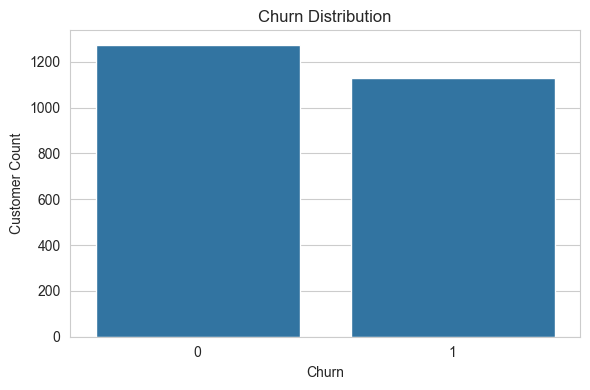

In [81]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=customer_master["churn_next_60d"]
)

plt.title(
    "Churn Distribution"
)

plt.xlabel("Churn")
plt.ylabel("Customer Count")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "churn_distribution.png",
    dpi=300
)

plt.show()

### Key Findings

- 1,127 customers churned within the next 60 days.
- 1,273 customers were retained.
- The overall churn rate is 46.96%.
- The dataset is relatively balanced between churned and retained customers.

### Business Insight

Nearly half of the customer base churns within the prediction window, indicating a significant retention challenge. The balanced target distribution is also favorable for future predictive modeling.

# Hypothesis 1

Customers with fewer orders are more likely to churn.

Purchase frequency is a strong indicator of customer engagement and loyalty. Customers who buy less frequently may be more likely to disengage from the platform.

In [82]:
hyp1 = (
    customer_master
    .groupby("churn_next_60d")
    ["total_orders"]
    .mean()
    .reset_index()
)

hyp1["churn_next_60d"] = (
    hyp1["churn_next_60d"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

display(hyp1)

hyp1.to_csv(
    TABLE_DIR /
    "hypothesis_1_order_frequency.csv",
    index=False
)

,churn_next_60d,total_orders
0,Retained,5.175177
1,Churned,3.035492


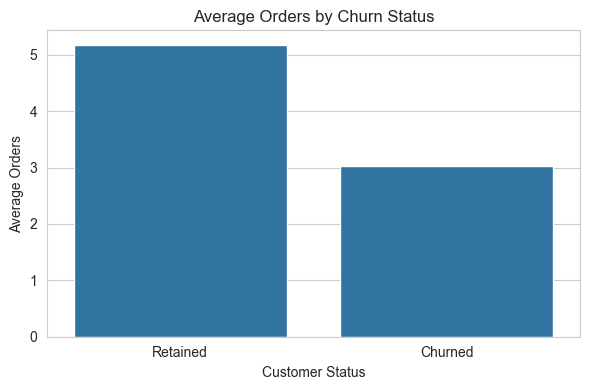

In [83]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=hyp1,
    x="churn_next_60d",
    y="total_orders"
)

plt.title(
    "Average Orders by Churn Status"
)

plt.xlabel("Customer Status")
plt.ylabel("Average Orders")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "hypothesis_1_order_frequency.png",
    dpi=300
)

plt.show()

### Evidence

| Customer Status | Average Orders |
|----------------|---------------:|
| Retained | 5.18 |
| Churned | 3.04 |

### Findings

- Retained customers place significantly more orders than churned customers.
- On average, retained customers complete approximately 70% more orders.
- Purchase frequency appears strongly associated with customer retention.

### Conclusion

The hypothesis is supported by the data. Customers with lower purchase frequency are substantially more likely to churn.

### Business Recommendation

Develop retention campaigns targeting low-frequency customers before they become inactive. Incentives such as loyalty rewards, personalized recommendations, and replenishment reminders may help increase repeat purchases.

# Hypothesis 2

Customers with lower platform engagement are more likely to churn.

Session activity reflects customer interest and interaction with the platform. Reduced engagement may indicate declining customer intent.

In [84]:
hyp2 = (
    customer_master
    .groupby("churn_next_60d")
    ["sessions_30d"]
    .mean()
    .reset_index()
)

hyp2["churn_next_60d"] = (
    hyp2["churn_next_60d"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

display(hyp2)

hyp2.to_csv(
    TABLE_DIR /
    "hypothesis_2_sessions.csv",
    index=False
)

,churn_next_60d,sessions_30d
0,Retained,6.732129
1,Churned,4.023070


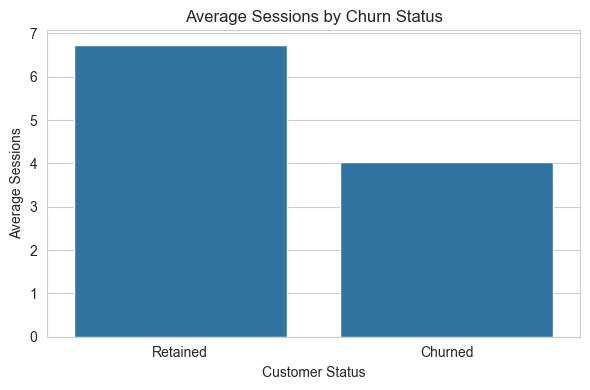

In [85]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=hyp2,
    x="churn_next_60d",
    y="sessions_30d"
)

plt.title(
    "Average Sessions by Churn Status"
)

plt.xlabel("Customer Status")
plt.ylabel("Average Sessions")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "hypothesis_2_sessions.png",
    dpi=300
)

plt.show()

### Evidence

| Customer Status | Average Sessions |
|----------------|-----------------:|
| Retained | 6.73 |
| Churned | 4.02 |

### Findings

- Retained customers exhibit substantially higher platform engagement.
- Churned customers average fewer than five sessions during the observation period.
- Session activity appears strongly associated with customer retention.

### Conclusion

The hypothesis is supported by the data. Customers with lower engagement levels are more likely to churn.

### Business Recommendation

Implement re-engagement campaigns for customers showing declining session activity. Personalized recommendations, targeted offers, and reminder notifications may help restore engagement.

# Hypothesis 3

Customers who have not visited the platform recently are more likely to churn.

Customer recency is a widely recognized indicator of engagement and future retention.

In [86]:
hyp3 = (
    customer_master
    .groupby("churn_next_60d")
    ["last_visit_days_ago"]
    .mean()
    .reset_index()
)

hyp3["churn_next_60d"] = (
    hyp3["churn_next_60d"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

display(hyp3)

hyp3.to_csv(
    TABLE_DIR /
    "hypothesis_3_recency.csv",
    index=False
)

,churn_next_60d,last_visit_days_ago
0,Retained,9.771406
1,Churned,26.554570


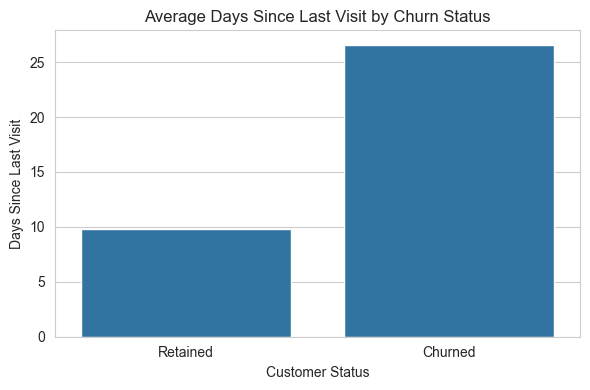

In [87]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=hyp3,
    x="churn_next_60d",
    y="last_visit_days_ago"
)

plt.title(
    "Average Days Since Last Visit by Churn Status"
)

plt.xlabel("Customer Status")
plt.ylabel("Days Since Last Visit")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "hypothesis_3_recency.png",
    dpi=300
)

plt.show()

### Evidence

| Customer Status | Avg. Days Since Last Visit |
|----------------|---------------------------:|
| Retained | 9.77 |
| Churned | 26.55 |

### Findings

- Churned customers have significantly longer inactivity periods.
- Retained customers visited the platform much more recently.
- Recency shows one of the strongest relationships with churn observed so far.

### Conclusion

The hypothesis is strongly supported by the data. Customers who have not visited the platform recently are substantially more likely to churn.

### Business Recommendation

Implement inactivity-triggered retention campaigns. Customers who have not visited within a predefined period should receive personalized offers, reminders, or engagement incentives.

# Hypothesis 4

Customers who are not enrolled in the loyalty program are more likely to churn.

Loyalty programs are designed to encourage repeat purchases and improve customer retention.

In [88]:
customer_master["loyalty_group"] = (
    customer_master["loyalty_tier"]
    .fillna("Not Enrolled")
)

hyp4 = (
    customer_master
    .groupby("loyalty_group")
    ["churn_next_60d"]
    .mean()
    .reset_index()
)

hyp4["churn_rate"] = (
    hyp4["churn_next_60d"] * 100
).round(2)

display(
    hyp4[
        ["loyalty_group", "churn_rate"]
    ]
)

hyp4.to_csv(
    TABLE_DIR /
    "hypothesis_4_loyalty.csv",
    index=False
)

,loyalty_group,churn_rate
0,Gold,40.75
1,Not Enrolled,48.34
2,Platinum,37.14
3,Silver,48.81


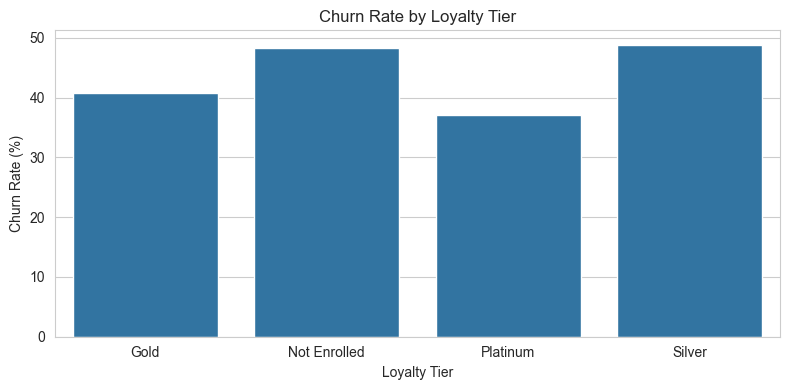

In [89]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=hyp4,
    x="loyalty_group",
    y="churn_rate"
)

plt.title(
    "Churn Rate by Loyalty Tier"
)

plt.xlabel("Loyalty Tier")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "hypothesis_4_loyalty.png",
    dpi=300
)

plt.show()

### Evidence

| Loyalty Group | Churn Rate (%) |
|--------------|---------------:|
| Platinum | 37.14 |
| Gold | 40.75 |
| Not Enrolled | 48.34 |
| Silver | 48.81 |

### Findings

- Platinum customers exhibit the lowest churn rate.
- Gold customers also show lower churn than the overall average.
- Silver customers have churn rates similar to non-enrolled customers.
- Higher loyalty tiers appear to be associated with improved retention.

### Conclusion

The hypothesis is partially supported. Premium loyalty tiers are associated with lower churn, while Silver membership alone does not appear sufficient to significantly improve retention.

### Business Recommendation

Encourage customers to progress beyond entry-level loyalty tiers through rewards, exclusive benefits, and personalized retention programs.

# Hypothesis 5

Customers with higher return rates are more likely to churn.

Returns may indicate dissatisfaction, product mismatch, or unmet expectations, which can negatively impact customer retention.

In [90]:
customer_master["return_rate"] = (
    customer_master["return_rate"]
    .fillna(0)
)

hyp5 = (
    customer_master
    .groupby("churn_next_60d")
    ["return_rate"]
    .mean()
    .reset_index()
)

hyp5["churn_next_60d"] = (
    hyp5["churn_next_60d"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

display(hyp5)

hyp5.to_csv(
    TABLE_DIR /
    "hypothesis_5_returns.csv",
    index=False
)

,churn_next_60d,return_rate
0,Retained,0.064451
1,Churned,0.082361


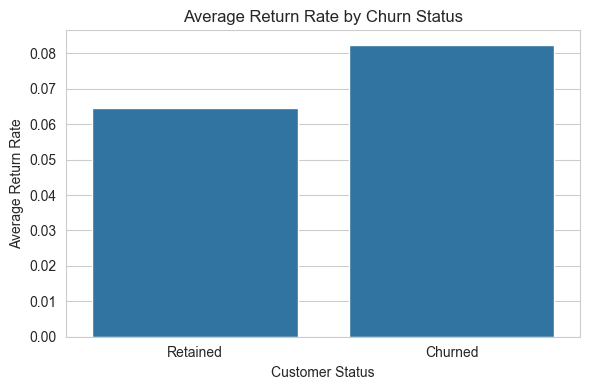

In [91]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=hyp5,
    x="churn_next_60d",
    y="return_rate"
)

plt.title(
    "Average Return Rate by Churn Status"
)

plt.xlabel("Customer Status")
plt.ylabel("Average Return Rate")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "hypothesis_5_returns.png",
    dpi=300
)

plt.show()

### Evidence

| Customer Status | Average Return Rate |
|----------------|--------------------:|
| Retained | 6.45% |
| Churned | 8.24% |

### Findings

- Churned customers exhibit a higher average return rate.
- Customers with frequent returns appear more likely to disengage from the platform.
- Return behavior may reflect dissatisfaction with products or customer experience.

### Conclusion

The hypothesis is supported by the data. Customers with higher return rates are more likely to churn.

### Business Recommendation

Monitor customers with repeated returns and proactively address product quality issues, expectation mismatches, and fulfillment problems before they impact retention.

# Hypothesis 6

Customers with more negative support sentiment are more likely to churn.

Negative customer sentiment may indicate dissatisfaction and an increased likelihood of leaving the platform.

In [92]:
customer_master["avg_sentiment"] = (
    customer_master["avg_sentiment"]
    .fillna(0)
)

hyp6 = (
    customer_master
    .groupby("churn_next_60d")
    ["avg_sentiment"]
    .mean()
    .reset_index()
)

hyp6["churn_next_60d"] = (
    hyp6["churn_next_60d"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

display(hyp6)

hyp6.to_csv(
    TABLE_DIR /
    "hypothesis_6_sentiment.csv",
    index=False
)

,churn_next_60d,avg_sentiment
0,Retained,-0.223016
1,Churned,-0.227364


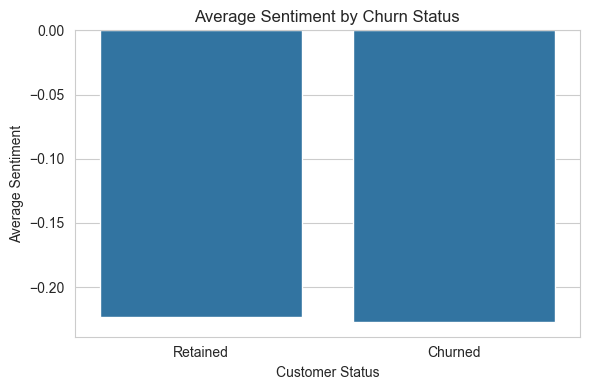

In [93]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=hyp6,
    x="churn_next_60d",
    y="avg_sentiment"
)

plt.title(
    "Average Sentiment by Churn Status"
)

plt.xlabel("Customer Status")
plt.ylabel("Average Sentiment")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "hypothesis_6_sentiment.png",
    dpi=300
)

plt.show()

### Evidence

| Customer Status | Average Sentiment |
|----------------|------------------:|
| Retained | -0.223 |
| Churned | -0.227 |

### Findings

- Both retained and churned customers exhibit very similar sentiment scores.
- The difference between the two groups is negligible.
- Negative sentiment does not appear to meaningfully differentiate churn behavior.

### Conclusion

The hypothesis is not supported by the data. Customer sentiment alone does not appear to be a strong predictor of churn in this dataset.

### Business Recommendation

While sentiment remains important for customer experience monitoring, other engagement and behavioral metrics appear to provide stronger signals for churn prediction.

# Hypothesis 7

Customers who engage less with marketing campaigns are more likely to churn.

Campaign interactions indicate customer interest and responsiveness to marketing efforts.

In [94]:
hyp7 = (
    customer_master
    .groupby("churn_next_60d")
    ["campaign_clicks_30d"]
    .mean()
    .reset_index()
)

hyp7["churn_next_60d"] = (
    hyp7["churn_next_60d"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

display(hyp7)

hyp7.to_csv(
    TABLE_DIR /
    "hypothesis_7_campaign_clicks.csv",
    index=False
)

,churn_next_60d,campaign_clicks_30d
0,Retained,0.736057
1,Churned,0.551908


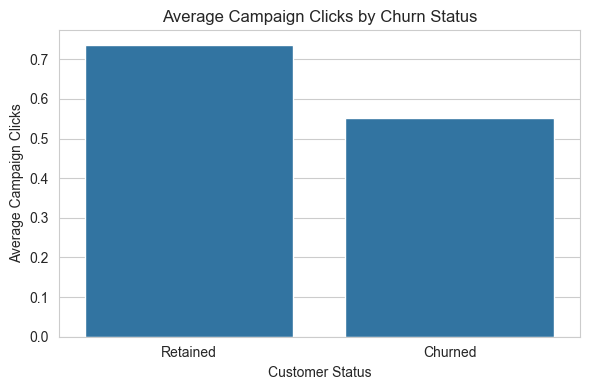

In [95]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=hyp7,
    x="churn_next_60d",
    y="campaign_clicks_30d"
)

plt.title(
    "Average Campaign Clicks by Churn Status"
)

plt.xlabel("Customer Status")
plt.ylabel("Average Campaign Clicks")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "hypothesis_7_campaign_clicks.png",
    dpi=300
)

plt.show()

### Evidence

| Customer Status | Average Campaign Clicks |
|----------------|------------------------:|
| Retained | 0.736 |
| Churned | 0.552 |

### Findings

- Retained customers interact with campaigns more frequently.
- Churned customers show lower marketing engagement.
- Campaign responsiveness appears positively associated with retention.

### Conclusion

The hypothesis is supported by the data. Customers who engage with marketing campaigns are less likely to churn.

### Business Recommendation

Increase personalized campaign targeting for low-engagement customers and monitor campaign interaction metrics as early warning signals for churn.

# Hypothesis 8

Customers with unresolved support issues are more likely to churn.

Ticket reopen rates may indicate unresolved customer problems and dissatisfaction with the support experience.

In [96]:
customer_master["reopen_rate"] = (
    customer_master["reopen_rate"]
    .fillna(0)
)

hyp8 = (
    customer_master
    .groupby("churn_next_60d")
    ["reopen_rate"]
    .mean()
    .reset_index()
)

hyp8["churn_next_60d"] = (
    hyp8["churn_next_60d"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

display(hyp8)

hyp8.to_csv(
    TABLE_DIR /
    "hypothesis_8_reopened_tickets.csv",
    index=False
)

,churn_next_60d,reopen_rate
0,Retained,0.091045
1,Churned,0.090240


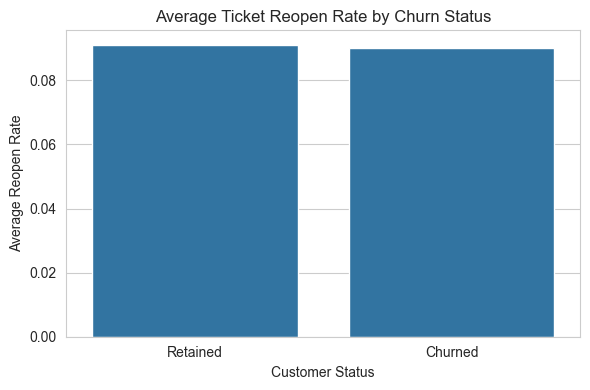

In [97]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=hyp8,
    x="churn_next_60d",
    y="reopen_rate"
)

plt.title(
    "Average Ticket Reopen Rate by Churn Status"
)

plt.xlabel("Customer Status")
plt.ylabel("Average Reopen Rate")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "hypothesis_8_reopened_tickets.png",
    dpi=300
)

plt.show()

### Evidence

| Customer Status | Average Reopen Rate |
|----------------|--------------------:|
| Retained | 0.091 |
| Churned | 0.090 |

### Findings

- Reopen rates are nearly identical across churned and retained customers.
- No meaningful relationship is observed between ticket reopening and churn.
- Reopened tickets do not appear to differentiate customer retention outcomes.

### Conclusion

The hypothesis is not supported by the data. Ticket reopen rates do not appear to be a significant churn driver in this dataset.

### Business Recommendation

Ticket reopen rates should continue to be monitored for service quality purposes, but they are unlikely to provide strong predictive value for churn modeling.

In [98]:
hypothesis_summary = pd.DataFrame({
    "Hypothesis": [
        "Low Order Frequency",
        "Low Session Activity",
        "High Inactivity (Recency)",
        "Loyalty Tier",
        "High Return Rate",
        "Negative Sentiment",
        "Low Campaign Engagement",
        "Reopened Tickets"
    ],
    "Result": [
        "Supported",
        "Supported",
        "Supported",
        "Partially Supported",
        "Supported",
        "Not Supported",
        "Supported",
        "Not Supported"
    ],
    "Strength": [
        "Strong",
        "Very Strong",
        "Very Strong",
        "Moderate",
        "Moderate",
        "Weak",
        "Strong",
        "Weak"
    ]
})

display(hypothesis_summary)

hypothesis_summary.to_csv(
    TABLE_DIR / "churn_hypothesis_summary.csv",
    index=False
)

print("✓ Churn hypothesis summary saved")

,Hypothesis,Result,Strength
0,Low Order Frequency,Supported,Strong
1,Low Session Activity,Supported,Very Strong
2,High Inactivity (Recency),Supported,Very Strong
3,Loyalty Tier,Partially Supported,Moderate
4,High Return Rate,Supported,Moderate
5,Negative Sentiment,Not Supported,Weak
6,Low Campaign Engagement,Supported,Strong
7,Reopened Tickets,Not Supported,Weak


✓ Churn hypothesis summary saved


In [99]:
key_findings = pd.DataFrame({
    "Priority": [1,2,3,4,5],
    "Finding": [
        "High inactivity strongly increases churn risk",
        "Low session activity increases churn risk",
        "Low purchase frequency increases churn risk",
        "Low campaign engagement increases churn risk",
        "Higher return rates are associated with churn"
    ]
})

display(key_findings)

key_findings.to_csv(
    TABLE_DIR / "key_business_findings.csv",
    index=False
)

print("✓ Key business findings saved")

,Priority,Finding
0,1,High inactivity strongly increases churn risk
1,2,Low session activity increases churn risk
2,3,Low purchase frequency increases churn risk
3,4,Low campaign engagement increases churn risk
4,5,Higher return rates are associated with churn


✓ Key business findings saved


# Executive Findings

## Most Significant Churn Drivers

Based on the analysis, the strongest indicators of churn are:

1. Customer inactivity (days since last visit).
2. Low session activity.
3. Low purchase frequency.
4. Low campaign engagement.
5. Higher return rates.

## Moderate Indicators

- Loyalty program participation appears beneficial at higher membership tiers.
- Gold and Platinum customers demonstrate lower churn rates than non-members.

## Weak Indicators

- Support-ticket sentiment shows little difference between churned and retained customers.
- Ticket reopen rates do not appear to meaningfully influence churn.

## Key Business Risk

Customers who stop visiting the platform and reduce engagement activity represent the highest-risk segment for future churn.

# Final Summary

## Strongest Churn Drivers Identified

| Rank | Driver | Strength |
|------|---------|----------|
| 1 | Customer Inactivity (Last Visit) | Very Strong |
| 2 | Session Activity | Very Strong |
| 3 | Order Frequency | Strong |
| 4 | Campaign Engagement | Strong |
| 5 | Return Rate | Moderate |

## Supported Hypotheses

- Low Order Frequency
- Low Session Activity
- High Inactivity
- High Return Rate
- Low Campaign Engagement

## Partially Supported Hypotheses

- Loyalty Tier

## Unsupported Hypotheses

- Negative Sentiment
- Reopened Tickets

## Final Business Recommendation

Retention efforts should prioritize customers showing declining engagement, increasing inactivity, and reduced purchasing frequency. These indicators consistently demonstrated the strongest relationship with churn and should form the basis of future intervention strategies.